In [1]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [2]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

1. Configuração
Por padrão, o gerador procura os notebooks na mesma pasta deste arquivo ou na pasta anterior.
Ajuste apenas os caminhos se a estrutura do repositório mudar.

In [3]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


##_______________________________________________________________ "" ____________________________________________________________

## _______________________________________________________________ "" ____________________________________________________________

In [18]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 1
# Identify payment events and build first-partial population
#
# Grain:
#   EVENT TABLE    = one row per observed payment response
#   JOURNEY TABLE  = one row per customer with a partial payment
#
# IMPORTANT:
# amount_paid_brl = payment observed within 72h after the message.
# Therefore sent_at is NOT the exact payment timestamp.
# We use payment_trigger_sent_at as the observable anchor.
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. PARAMETERS
# ------------------------------------------------------------

TOLERANCE_BRL = 0.05
DISCOUNT_SETTLEMENT_RATE = 0.85

# ------------------------------------------------------------
# 1. COPY + BASIC TYPES
# ------------------------------------------------------------

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["paid_within_72h"] = pd.to_numeric(
    df["paid_within_72h"],
    errors="coerce"
).fillna(0).astype(int)

df = (
    df
    .sort_values(["customer_id", "sent_at", "message_id"])
    .reset_index(drop=True)
)

print("=" * 80)
print("BASE")
print("=" * 80)
print(f"Rows       : {len(df):,}")
print(f"Customers  : {df['customer_id'].nunique():,}")
print()


# ============================================================
# 2. IDENTIFY OBSERVED PAYMENT RESPONSES
# ============================================================

df["has_payment"] = (
    (df["paid_within_72h"] == 1) &
    (df["amount_paid_brl"] > TOLERANCE_BRL)
)

payment_events = (
    df.loc[df["has_payment"]]
    .copy()
    .rename(columns={"sent_at": "payment_trigger_sent_at"})
)

print("=" * 80)
print("OBSERVED PAYMENT RESPONSES")
print("=" * 80)
print(f"Payment-response rows : {len(payment_events):,}")
print(
    f"Customers with payment: "
    f"{payment_events['customer_id'].nunique():,}"
)
print()


# ============================================================
# 3. SETTLEMENT THRESHOLD
#
# Regular templates:
#     full settlement ≈ outstanding balance
#
# discount_offer:
#     full settlement ≈ 85% of outstanding balance
# ============================================================

payment_events["discount_offer_flag"] = (
    payment_events["template"]
    .astype(str)
    .str.lower()
    .eq("discount_offer")
)

payment_events["settlement_threshold_brl"] = np.where(
    payment_events["discount_offer_flag"],
    payment_events["outstanding_balance_brl"]
        * DISCOUNT_SETTLEMENT_RATE,
    payment_events["outstanding_balance_brl"]
)

# ------------------------------------------------------------
# Payment as % of balance at the trigger message
# ------------------------------------------------------------

payment_events["payment_pct_of_balance"] = np.where(
    payment_events["outstanding_balance_brl"] > 0,
    (
        payment_events["amount_paid_brl"]
        / payment_events["outstanding_balance_brl"]
    ),
    np.nan
)

# ------------------------------------------------------------
# Payment as % of settlement requirement
#
# Particularly useful for discount_offer because 85% = 100%
# of required settlement amount.
# ------------------------------------------------------------

payment_events["payment_pct_of_settlement_threshold"] = np.where(
    payment_events["settlement_threshold_brl"] > 0,
    (
        payment_events["amount_paid_brl"]
        / payment_events["settlement_threshold_brl"]
    ),
    np.nan
)


# ============================================================
# 4. CLASSIFY PAYMENT EVENT
# ============================================================

payment_events["payment_type"] = np.where(
    payment_events["amount_paid_brl"]
    >= (
        payment_events["settlement_threshold_brl"]
        - TOLERANCE_BRL
    ),
    "FULL_SETTLEMENT",
    "PARTIAL_PAYMENT"
)

payment_events["partial_payment_flag"] = (
    payment_events["payment_type"] == "PARTIAL_PAYMENT"
)

payment_events["full_settlement_flag"] = (
    payment_events["payment_type"] == "FULL_SETTLEMENT"
)

# ------------------------------------------------------------
# Approximate residual balance immediately after response
#
# IMPORTANT:
# For discount_offer that settles the debt, residual economic
# balance is zero.
# ------------------------------------------------------------

payment_events["estimated_remaining_balance_brl"] = np.where(
    payment_events["full_settlement_flag"],
    0.0,
    np.maximum(
        payment_events["outstanding_balance_brl"]
        - payment_events["amount_paid_brl"],
        0
    )
)


# ============================================================
# 5. VALIDATION — PAYMENT CLASSIFICATION
# ============================================================

payment_summary = (
    payment_events
    .groupby("payment_type", observed=True)
    .agg(
        payment_events=("message_id", "count"),
        customers=("customer_id", "nunique"),
        amount_paid_brl=("amount_paid_brl", "sum")
    )
    .reset_index()
)

payment_summary["pct_payment_events"] = (
    payment_summary["payment_events"]
    / payment_summary["payment_events"].sum()
    * 100
)

payment_summary = payment_summary[
    [
        "payment_type",
        "payment_events",
        "pct_payment_events",
        "customers",
        "amount_paid_brl"
    ]
]

print("=" * 80)
print("PAYMENT CLASSIFICATION")
print("=" * 80)

display(
    payment_summary.style.format(
        {
            "payment_events": "{:,.0f}",
            "pct_payment_events": "{:.1f}%",
            "customers": "{:,.0f}",
            "amount_paid_brl": "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 6. PARTIAL PAYMENT EVENTS ONLY
# ============================================================

partial_events = (
    payment_events.loc[
        payment_events["partial_payment_flag"]
    ]
    .copy()
)

print()
print("=" * 80)
print("PARTIAL PAYMENT EVENTS")
print("=" * 80)
print(f"Partial payment events : {len(partial_events):,}")
print(
    f"Partial payers         : "
    f"{partial_events['customer_id'].nunique():,}"
)
print(
    f"Partial amount paid    : "
    f"R$ {partial_events['amount_paid_brl'].sum():,.2f}"
)
print()


# ============================================================
# 7. FIRST PARTIAL PAYMENT PER CUSTOMER
#
# This becomes T0 for the partial-payer analysis.
#
# Remember:
# T0 = message timestamp associated with the first observed
# partial-payment response, NOT exact payment timestamp.
# ============================================================

first_partial = (
    partial_events
    .sort_values(
        [
            "customer_id",
            "payment_trigger_sent_at",
            "message_id"
        ]
    )
    .groupby("customer_id", as_index=False)
    .first()
)

# Rename important T0 variables

first_partial = first_partial.rename(
    columns={
        "payment_trigger_sent_at":
            "first_partial_trigger_sent_at",

        "amount_paid_brl":
            "first_partial_amount_brl",

        "outstanding_balance_brl":
            "balance_at_first_partial_brl",

        "estimated_remaining_balance_brl":
            "estimated_remaining_after_first_partial_brl",

        "days_past_due":
            "dpd_at_first_partial",

        "template":
            "template_at_first_partial",

        "payment_pct_of_balance":
            "first_partial_pct_of_balance",

        "payment_pct_of_settlement_threshold":
            "first_partial_pct_of_settlement_threshold"
    }
)


# ============================================================
# 8. OBSERVATION HORIZON
#
# History ends at the last timestamp actually present in file.
# ============================================================

DATA_END = df["sent_at"].max()

first_partial["days_from_trigger_to_data_end"] = (
    DATA_END
    - first_partial["first_partial_trigger_sent_at"]
).dt.total_seconds() / 86400


# ============================================================
# 9. MATURITY FLAGS
#
# Because the payment itself can occur up to 72h after the
# trigger message, communication analysis requires care.
#
# Here we create simple dataset-horizon flags first.
# ============================================================

for days in [3, 7, 14, 30]:

    first_partial[f"observable_{days}d_after_trigger"] = (
        first_partial["days_from_trigger_to_data_end"] >= days
    )


# ============================================================
# 10. PAYMENT PROFILE AT FIRST PARTIAL
# ============================================================

def payment_share_bucket(x):

    if pd.isna(x):
        return "Unknown"

    if x <= 0.10:
        return "01. <=10%"

    elif x <= 0.25:
        return "02. 10-25%"

    elif x <= 0.50:
        return "03. 25-50%"

    elif x <= 0.75:
        return "04. 50-75%"

    else:
        return "05. >75%"


first_partial["first_partial_share_bucket"] = (
    first_partial["first_partial_pct_of_balance"]
    .apply(payment_share_bucket)
)


# ------------------------------------------------------------
# DPD bucket
# ------------------------------------------------------------

first_partial["dpd_bucket_at_first_partial"] = pd.cut(
    first_partial["dpd_at_first_partial"],
    bins=[-np.inf, 15, 30, 45, 60, np.inf],
    labels=[
        "01. DPD <=15",
        "02. DPD 16-30",
        "03. DPD 31-45",
        "04. DPD 46-60",
        "05. DPD >60"
    ]
)


# ============================================================
# 11. FIRST PARTIAL POPULATION PROFILE
# ============================================================

partial_population_profile = pd.DataFrame(
    {
        "metric": [
            "Partial payers",
            "First partial amount",
            "Balance at first partial",
            "Estimated remaining balance",
            "Median first partial amount",
            "Median % balance paid",
            "Median DPD at first partial",
            "Observable >= 7d",
            "Observable >= 14d"
        ],

        "value": [
            len(first_partial),

            first_partial[
                "first_partial_amount_brl"
            ].sum(),

            first_partial[
                "balance_at_first_partial_brl"
            ].sum(),

            first_partial[
                "estimated_remaining_after_first_partial_brl"
            ].sum(),

            first_partial[
                "first_partial_amount_brl"
            ].median(),

            first_partial[
                "first_partial_pct_of_balance"
            ].median(),

            first_partial[
                "dpd_at_first_partial"
            ].median(),

            first_partial[
                "observable_7d_after_trigger"
            ].sum(),

            first_partial[
                "observable_14d_after_trigger"
            ].sum()
        ]
    }
)

print("=" * 80)
print("FIRST PARTIAL PAYMENT POPULATION")
print("=" * 80)

display(partial_population_profile)


# ============================================================
# 12. DISTRIBUTION — HOW MUCH DID THEY PAY?
# ============================================================

partial_share_distribution = (
    first_partial
    .groupby(
        "first_partial_share_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        balance_at_partial_brl=(
            "balance_at_first_partial_brl",
            "sum"
        ),

        partial_paid_brl=(
            "first_partial_amount_brl",
            "sum"
        ),

        remaining_balance_brl=(
            "estimated_remaining_after_first_partial_brl",
            "sum"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        )
    )
    .reset_index()
)

partial_share_distribution["pct_customers"] = (
    partial_share_distribution["customers"]
    / partial_share_distribution["customers"].sum()
    * 100
)

partial_share_distribution = partial_share_distribution[
    [
        "first_partial_share_bucket",
        "customers",
        "pct_customers",
        "balance_at_partial_brl",
        "partial_paid_brl",
        "remaining_balance_brl",
        "median_dpd"
    ]
]

print()
print("=" * 80)
print("PARTIAL PAYMENT SIZE PROFILE")
print("=" * 80)

display(
    partial_share_distribution.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "balance_at_partial_brl": "R$ {:,.2f}",
            "partial_paid_brl": "R$ {:,.2f}",
            "remaining_balance_brl": "R$ {:,.2f}",
            "median_dpd": "{:.0f}"
        }
    )
)


# ============================================================
# 13. DISTRIBUTION BY DPD
# ============================================================

partial_dpd_distribution = (
    first_partial
    .groupby(
        "dpd_bucket_at_first_partial",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        partial_paid_brl=(
            "first_partial_amount_brl",
            "sum"
        ),

        remaining_balance_brl=(
            "estimated_remaining_after_first_partial_brl",
            "sum"
        )
    )
    .reset_index()
)

partial_dpd_distribution["pct_customers"] = (
    partial_dpd_distribution["customers"]
    / partial_dpd_distribution["customers"].sum()
    * 100
)

print()
print("=" * 80)
print("PARTIAL PAYERS BY DPD")
print("=" * 80)

display(
    partial_dpd_distribution.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "median_partial_pct": "{:.1%}",
            "partial_paid_brl": "R$ {:,.2f}",
            "remaining_balance_brl": "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 14. FINAL ANALYTICAL DATASET
# ============================================================

keep_cols = [
    "customer_id",

    "first_partial_trigger_sent_at",

    "dpd_at_first_partial",

    "template_at_first_partial",

    "balance_at_first_partial_brl",

    "first_partial_amount_brl",

    "first_partial_pct_of_balance",

    "first_partial_pct_of_settlement_threshold",

    "estimated_remaining_after_first_partial_brl",

    "first_partial_share_bucket",

    "dpd_bucket_at_first_partial",

    "days_from_trigger_to_data_end",

    "observable_3d_after_trigger",

    "observable_7d_after_trigger",

    "observable_14d_after_trigger",

    "observable_30d_after_trigger"
]

partial_payment_journey = (
    first_partial[keep_cols]
    .copy()
    .sort_values("first_partial_trigger_sent_at")
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("PARTIAL_PAYMENT_JOURNEY CREATED")
print("=" * 80)

print(
    f"Rows      : {len(partial_payment_journey):,}"
)

print(
    f"Customers : "
    f"{partial_payment_journey['customer_id'].nunique():,}"
)

print()

display(partial_payment_journey.head(10))

BASE
Rows       : 75,406
Customers  : 11,724

OBSERVED PAYMENT RESPONSES
Payment-response rows : 5,626
Customers with payment: 4,893

PAYMENT CLASSIFICATION


,payment_type,payment_events,pct_payment_events,customers,amount_paid_brl
0,FULL_SETTLEMENT,"3,641",64.7%,"3,641","R$ 2,699,477.41"
1,PARTIAL_PAYMENT,"1,985",35.3%,"1,746","R$ 759,827.89"



PARTIAL PAYMENT EVENTS
Partial payment events : 1,985
Partial payers         : 1,746
Partial amount paid    : R$ 759,827.89

FIRST PARTIAL PAYMENT POPULATION


,metric,value
0,Partial payers,"1,746.00"
1,First partial amount,"718,882.02"
2,Balance at first partial,"1,416,663.63"
3,Estimated remaining balance,"697,781.61"
4,Median first partial amount,335.97
5,Median % balance paid,0.51
6,Median DPD at first partial,9.00
7,Observable >= 7d,"1,576.00"
8,Observable >= 14d,"1,436.00"



PARTIAL PAYMENT SIZE PROFILE


,first_partial_share_bucket,customers,pct_customers,balance_at_partial_brl,partial_paid_brl,remaining_balance_brl,median_dpd
0,03. 25-50%,826,47.3%,"R$ 678,626.48","R$ 255,637.29","R$ 422,989.19",8
1,04. 50-75%,920,52.7%,"R$ 738,037.15","R$ 463,244.73","R$ 274,792.42",9



PARTIAL PAYERS BY DPD


,dpd_bucket_at_first_partial,customers,median_partial_pct,partial_paid_brl,remaining_balance_brl,pct_customers
0,01. DPD <=15,"1,316",51.3%,"R$ 534,267.59","R$ 519,570.05",75.4%
1,02. DPD 16-30,288,51.7%,"R$ 120,397.76","R$ 117,244.99",16.5%
2,03. DPD 31-45,104,53.7%,"R$ 47,476.56","R$ 43,430.78",6.0%
3,04. DPD 46-60,38,46.3%,"R$ 16,740.11","R$ 17,535.79",2.2%
4,05. DPD >60,0,nan%,R$ 0.00,R$ 0.00,0.0%



PARTIAL_PAYMENT_JOURNEY CREATED
Rows      : 1,746
Customers : 1,746



,customer_id,first_partial_trigger_sent_at,dpd_at_first_partial,template_at_first_partial,balance_at_first_partial_brl,first_partial_amount_brl,first_partial_pct_of_balance,first_partial_pct_of_settlement_threshold,estimated_remaining_after_first_partial_brl,first_partial_share_bucket,dpd_bucket_at_first_partial,days_from_trigger_to_data_end,observable_3d_after_trigger,observable_7d_after_trigger,observable_14d_after_trigger,observable_30d_after_trigger
0,C009154,2026-06-01 10:28:00,1,friendly_reminder,956.03,263.95,0.28,0.28,692.08,03. 25-50%,01. DPD <=15,91.44,True,True,True,True
1,C000510,2026-06-01 10:53:00,1,pix_link,567.74,274.14,0.48,0.48,293.60,03. 25-50%,01. DPD <=15,91.42,True,True,True,True
2,C003731,2026-06-02 11:33:00,2,pix_link,293.86,109.19,0.37,0.37,184.67,03. 25-50%,01. DPD <=15,90.39,True,True,True,True
3,C005839,2026-06-03 11:39:00,1,pix_link,972.01,561.73,0.58,0.58,410.28,04. 50-75%,01. DPD <=15,89.39,True,True,True,True
4,C004528,2026-06-03 13:40:00,2,pix_link,451.79,325.26,0.72,0.72,126.53,04. 50-75%,01. DPD <=15,89.30,True,True,True,True
5,C000679,2026-06-04 09:28:00,1,friendly_reminder,"1,373.19",758.81,0.55,0.55,614.38,04. 50-75%,01. DPD <=15,88.48,True,True,True,True
6,C002235,2026-06-04 11:52:00,3,friendly_reminder,944.73,275.95,0.29,0.29,668.78,03. 25-50%,01. DPD <=15,88.38,True,True,True,True
7,C010968,2026-06-04 18:13:00,1,friendly_reminder,250.05,122.60,0.49,0.49,127.45,03. 25-50%,01. DPD <=15,88.12,True,True,True,True
8,C011495,2026-06-05 09:54:00,2,pix_link,573.42,347.49,0.61,0.61,225.93,04. 50-75%,01. DPD <=15,87.46,True,True,True,True
9,C002700,2026-06-05 10:21:00,5,pix_link,411.60,249.14,0.61,0.61,162.46,04. 50-75%,01. DPD <=15,87.44,True,True,True,True


In [6]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 2
# POST-PARTIAL COMMUNICATION AUDIT
#
# Question:
# After showing payment intent through a partial payment,
# do we continue contacting the customer?
#
# Conservative timing rule:
# payment is observed within 72h after trigger message.
# Therefore:
#     post-partial communication starts at trigger + 72h
#
# Grain:
#     1 row per partial payer
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. PREPARE BASE
# ------------------------------------------------------------

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df = (
    df
    .sort_values(["customer_id", "sent_at", "message_id"])
    .reset_index(drop=True)
)

DATA_END = df["sent_at"].max()


# ============================================================
# 1. START FROM FIRST PARTIAL TABLE
# ============================================================

journey = partial_payment_journey.copy()

journey["first_partial_trigger_sent_at"] = pd.to_datetime(
    journey["first_partial_trigger_sent_at"]
)

# Conservative boundary:
# payment attributed to trigger occurs somewhere inside these 72h

journey["partial_response_window_end"] = (
    journey["first_partial_trigger_sent_at"]
    + pd.Timedelta(hours=72)
)

# ------------------------------------------------------------
# True observable time AFTER the payment attribution window
# ------------------------------------------------------------

journey["post_partial_observation_days"] = (
    DATA_END
    - journey["partial_response_window_end"]
).dt.total_seconds() / 86400

for days in [3, 7, 14, 30]:

    journey[f"mature_post_partial_{days}d"] = (
        journey["post_partial_observation_days"] >= days
    )


# ============================================================
# 2. ATTACH T0 TO ALL WHATSAPP RECORDS
# ============================================================

anchor = journey[
    [
        "customer_id",
        "first_partial_trigger_sent_at",
        "partial_response_window_end"
    ]
].copy()

wa_partial = (
    df
    .merge(
        anchor,
        on="customer_id",
        how="inner"
    )
)

# ------------------------------------------------------------
# PRE-PARTIAL
#
# Strictly before trigger message
# ------------------------------------------------------------

wa_partial["is_pre_partial"] = (
    wa_partial["sent_at"]
    < wa_partial["first_partial_trigger_sent_at"]
)

# ------------------------------------------------------------
# POST-PARTIAL
#
# Strict conservative definition:
# after the 72h response window
# ------------------------------------------------------------

wa_partial["is_post_partial"] = (
    wa_partial["sent_at"]
    > wa_partial["partial_response_window_end"]
)

post = (
    wa_partial.loc[
        wa_partial["is_post_partial"]
    ]
    .copy()
)

pre = (
    wa_partial.loc[
        wa_partial["is_pre_partial"]
    ]
    .copy()
)


# ============================================================
# 3. POST-PARTIAL MESSAGE COUNTS
# ============================================================

post_summary = (
    post
    .groupby("customer_id")
    .agg(
        post_partial_messages=("message_id", "count"),

        first_post_partial_contact=("sent_at", "min"),

        last_post_partial_contact=("sent_at", "max"),

        post_partial_contact_days=(
            "sent_at",
            lambda x: x.dt.date.nunique()
        )
    )
    .reset_index()
)

journey = journey.merge(
    post_summary,
    on="customer_id",
    how="left"
)

journey["post_partial_messages"] = (
    journey["post_partial_messages"]
    .fillna(0)
    .astype(int)
)

journey["post_partial_contact_days"] = (
    journey["post_partial_contact_days"]
    .fillna(0)
    .astype(int)
)

journey["contacted_after_partial"] = (
    journey["post_partial_messages"] > 0
)

journey["never_contacted_after_partial"] = (
    journey["post_partial_messages"] == 0
)


# ============================================================
# 4. TIME TO NEXT CONTACT
# ============================================================

journey["days_to_next_contact_after_partial"] = (
    journey["first_post_partial_contact"]
    - journey["partial_response_window_end"]
).dt.total_seconds() / 86400


# ============================================================
# 5. MESSAGE COUNTS WITHIN FIXED WINDOWS
# ============================================================

for days in [3, 7, 14, 30]:

    temp = (
        wa_partial.loc[
            (
                wa_partial["sent_at"]
                > wa_partial["partial_response_window_end"]
            )
            &
            (
                wa_partial["sent_at"]
                <= (
                    wa_partial["partial_response_window_end"]
                    + pd.Timedelta(days=days)
                )
            )
        ]
        .groupby("customer_id")
        .agg(
            **{
                f"messages_post_partial_{days}d":
                    ("message_id", "count")
            }
        )
        .reset_index()
    )

    journey = journey.merge(
        temp,
        on="customer_id",
        how="left"
    )

    journey[f"messages_post_partial_{days}d"] = (
        journey[f"messages_post_partial_{days}d"]
        .fillna(0)
        .astype(int)
    )

    journey[f"contacted_post_partial_{days}d"] = (
        journey[f"messages_post_partial_{days}d"] > 0
    )


# ============================================================
# 6. PRE-PARTIAL COMMUNICATION
#
# Compare 7 days BEFORE trigger vs 7 days AFTER response window.
# ============================================================

pre_7d = (
    wa_partial.loc[
        (
            wa_partial["sent_at"]
            < wa_partial["first_partial_trigger_sent_at"]
        )
        &
        (
            wa_partial["sent_at"]
            >= (
                wa_partial["first_partial_trigger_sent_at"]
                - pd.Timedelta(days=7)
            )
        )
    ]
    .groupby("customer_id")
    .agg(
        messages_pre_partial_7d=("message_id", "count")
    )
    .reset_index()
)

journey = journey.merge(
    pre_7d,
    on="customer_id",
    how="left"
)

journey["messages_pre_partial_7d"] = (
    journey["messages_pre_partial_7d"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 7. PRIMARY TABLE — 7 DAY MATURE POPULATION
# ============================================================

mature_7d = journey.loc[
    journey["mature_post_partial_7d"]
].copy()

n_mature = len(mature_7d)

n_contacted = (
    mature_7d["contacted_post_partial_7d"]
    .sum()
)

n_silent = (
    (~mature_7d["contacted_post_partial_7d"])
    .sum()
)

pct_contacted = (
    n_contacted / n_mature * 100
    if n_mature > 0 else np.nan
)

pct_silent = (
    n_silent / n_mature * 100
    if n_mature > 0 else np.nan
)

silent_balance = (
    mature_7d.loc[
        ~mature_7d["contacted_post_partial_7d"],
        "estimated_remaining_after_first_partial_brl"
    ]
    .sum()
)

contacted_balance = (
    mature_7d.loc[
        mature_7d["contacted_post_partial_7d"],
        "estimated_remaining_after_first_partial_brl"
    ]
    .sum()
)

total_remaining_balance = (
    mature_7d[
        "estimated_remaining_after_first_partial_brl"
    ]
    .sum()
)

silent_balance_share = (
    silent_balance
    / total_remaining_balance
    * 100
    if total_remaining_balance > 0
    else np.nan
)


post_partial_7d_summary = pd.DataFrame(
    {
        "metric": [
            "Mature partial payers",
            "Contacted within 7d",
            "No contact within 7d",
            "Contacted within 7d (%)",
            "No contact within 7d (%)",
            "Remaining balance — contacted",
            "Remaining balance — no contact",
            "Total remaining balance",
            "Share balance in no-contact group"
        ],

        "value": [
            n_mature,
            n_contacted,
            n_silent,
            pct_contacted,
            pct_silent,
            contacted_balance,
            silent_balance,
            total_remaining_balance,
            silent_balance_share
        ]
    }
)

print("=" * 85)
print("POST-PARTIAL COMMUNICATION — 7 DAY WINDOW")
print("=" * 85)

display(post_partial_7d_summary)


# ============================================================
# 8. CONTACT RATE BY WINDOW
# ============================================================

window_results = []

for days in [3, 7, 14, 30]:

    eligible = journey.loc[
        journey[f"mature_post_partial_{days}d"]
    ].copy()

    n = len(eligible)

    contacted = (
        eligible[
            f"contacted_post_partial_{days}d"
        ].sum()
    )

    silent = n - contacted

    balance_silent = (
        eligible.loc[
            ~eligible[
                f"contacted_post_partial_{days}d"
            ],
            "estimated_remaining_after_first_partial_brl"
        ]
        .sum()
    )

    total_balance = (
        eligible[
            "estimated_remaining_after_first_partial_brl"
        ]
        .sum()
    )

    window_results.append(
        {
            "window_days": days,

            "eligible_partial_payers": n,

            "contacted": contacted,

            "not_contacted": silent,

            "contact_rate_pct":
                contacted / n * 100
                if n > 0 else np.nan,

            "no_contact_rate_pct":
                silent / n * 100
                if n > 0 else np.nan,

            "remaining_balance_no_contact_brl":
                balance_silent,

            "share_remaining_balance_no_contact_pct":
                (
                    balance_silent
                    / total_balance
                    * 100
                    if total_balance > 0
                    else np.nan
                )
        }
    )

contact_by_window = pd.DataFrame(window_results)

print()
print("=" * 85)
print("POST-PARTIAL CONTACT RATE BY WINDOW")
print("=" * 85)

display(
    contact_by_window.style.format(
        {
            "eligible_partial_payers": "{:,.0f}",
            "contacted": "{:,.0f}",
            "not_contacted": "{:,.0f}",
            "contact_rate_pct": "{:.1f}%",
            "no_contact_rate_pct": "{:.1f}%",
            "remaining_balance_no_contact_brl":
                "R$ {:,.2f}",
            "share_remaining_balance_no_contact_pct":
                "{:.1f}%"
        }
    )
)


# ============================================================
# 9. TIME TO NEXT CONTACT
#
# Only customers eventually contacted after the partial.
# ============================================================

contacted_eventually = journey.loc[
    journey["contacted_after_partial"]
].copy()

def contact_gap_bucket(x):

    if pd.isna(x):
        return "Never contacted"

    elif x <= 1:
        return "01. <=1 day"

    elif x <= 3:
        return "02. 1-3 days"

    elif x <= 7:
        return "03. 3-7 days"

    elif x <= 14:
        return "04. 7-14 days"

    else:
        return "05. >14 days"


journey["next_contact_gap_bucket"] = (
    journey["days_to_next_contact_after_partial"]
    .apply(contact_gap_bucket)
)

gap_distribution = (
    journey
    .groupby(
        "next_contact_gap_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        remaining_balance_brl=(
            "estimated_remaining_after_first_partial_brl",
            "sum"
        )
    )
    .reset_index()
)

gap_distribution["pct_customers"] = (
    gap_distribution["customers"]
    / gap_distribution["customers"].sum()
    * 100
)

print()
print("=" * 85)
print("TIME TO NEXT CONTACT AFTER PARTIAL")
print("=" * 85)

display(
    gap_distribution.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "remaining_balance_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 10. BEFORE VS AFTER COMMUNICATION
#
# Restrict to mature 7d population.
# ============================================================

cadence_7d = mature_7d.copy()

cadence_summary = pd.DataFrame(
    {
        "period": [
            "7d before partial trigger",
            "7d after partial response window"
        ],

        "avg_messages_per_customer": [
            cadence_7d[
                "messages_pre_partial_7d"
            ].mean(),

            cadence_7d[
                "messages_post_partial_7d"
            ].mean()
        ],

        "median_messages_per_customer": [
            cadence_7d[
                "messages_pre_partial_7d"
            ].median(),

            cadence_7d[
                "messages_post_partial_7d"
            ].median()
        ],

        "total_messages": [
            cadence_7d[
                "messages_pre_partial_7d"
            ].sum(),

            cadence_7d[
                "messages_post_partial_7d"
            ].sum()
        ]
    }
)

print()
print("=" * 85)
print("COMMUNICATION CADENCE — BEFORE VS AFTER PARTIAL")
print("=" * 85)

display(
    cadence_summary.style.format(
        {
            "avg_messages_per_customer": "{:.2f}",
            "median_messages_per_customer": "{:.1f}",
            "total_messages": "{:,.0f}"
        }
    )
)


# ============================================================
# 11. SILENT PARTIAL PAYERS — PROFILE
#
# 7-day mature + no contact in next 7 days
# ============================================================

silent_7d = (
    mature_7d.loc[
        ~mature_7d["contacted_post_partial_7d"]
    ]
    .copy()
)

silent_profile = pd.DataFrame(
    {
        "metric": [
            "Customers",
            "Remaining balance",
            "Average remaining balance",
            "Median remaining balance",
            "Median partial payment",
            "Median % balance already paid",
            "Median DPD at partial"
        ],

        "value": [
            len(silent_7d),

            silent_7d[
                "estimated_remaining_after_first_partial_brl"
            ].sum(),

            silent_7d[
                "estimated_remaining_after_first_partial_brl"
            ].mean(),

            silent_7d[
                "estimated_remaining_after_first_partial_brl"
            ].median(),

            silent_7d[
                "first_partial_amount_brl"
            ].median(),

            silent_7d[
                "first_partial_pct_of_balance"
            ].median(),

            silent_7d[
                "dpd_at_first_partial"
            ].median()
        ]
    }
)

print()
print("=" * 85)
print("SILENT PARTIAL PAYERS — 7 DAY WINDOW")
print("=" * 85)

display(silent_profile)


# ============================================================
# 12. SAVE UPDATED JOURNEY IN MEMORY
# ============================================================

partial_payment_journey_v2 = journey.copy()

print()
print("=" * 85)
print("PARTIAL_PAYMENT_JOURNEY_V2 CREATED")
print("=" * 85)

print(
    f"Rows      : "
    f"{len(partial_payment_journey_v2):,}"
)

print(
    f"Customers : "
    f"{partial_payment_journey_v2['customer_id'].nunique():,}"
)

POST-PARTIAL COMMUNICATION — 7 DAY WINDOW


,metric,value
0,Mature partial payers,"1,531.00"
1,Contacted within 7d,"1,218.00"
2,No contact within 7d,313.00
3,Contacted within 7d (%),79.56
4,No contact within 7d (%),20.44
5,Remaining balance — contacted,"483,667.80"
6,Remaining balance — no contact,"125,878.37"
7,Total remaining balance,"609,546.17"
8,Share balance in no-contact group,20.65



POST-PARTIAL CONTACT RATE BY WINDOW


,window_days,eligible_partial_payers,contacted,not_contacted,contact_rate_pct,no_contact_rate_pct,remaining_balance_no_contact_brl,share_remaining_balance_no_contact_pct
0,3,"1,606",748,858,46.6%,53.4%,"R$ 333,539.47",52.2%
1,7,"1,531","1,218",313,79.6%,20.4%,"R$ 125,878.37",20.7%
2,14,"1,393","1,317",76,94.5%,5.5%,"R$ 32,460.31",5.8%
3,30,"1,031","1,019",12,98.8%,1.2%,"R$ 5,026.93",1.2%



TIME TO NEXT CONTACT AFTER PARTIAL


...


COMMUNICATION CADENCE — BEFORE VS AFTER PARTIAL


,period,avg_messages_per_customer,median_messages_per_customer,total_messages
0,7d before partial trigger,1.13,1.0,"1,734"
1,7d after partial response window,1.37,1.0,"2,098"



SILENT PARTIAL PAYERS — 7 DAY WINDOW


,metric,value
0,Customers,313.00
1,Remaining balance,"125,878.37"
2,Average remaining balance,402.17
3,Median remaining balance,345.42
4,Median partial payment,354.81
5,Median % balance already paid,0.52
6,Median DPD at partial,14.00



PARTIAL_PAYMENT_JOURNEY_V2 CREATED
Rows      : 1,746
Customers : 1,746


In [7]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 3
# PAYMENT MOMENTUM AFTER FIRST PARTIAL
#
# Questions:
# 1. How many partial payers pay again?
# 2. How many eventually fully settle?
# 3. How much additional money is recovered?
# 4. How quickly does the next observed payment response occur?
#
# IMPORTANT:
# sent_at is the trigger-message timestamp, not exact payment time.
# Therefore time gaps below are between payment-response triggers.
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PAYMENT EVENTS ALREADY CREATED IN STEP 1
# ------------------------------------------------------------

payments = payment_events.copy()

payments["payment_trigger_sent_at"] = pd.to_datetime(
    payments["payment_trigger_sent_at"]
)

# First partial anchor
anchor = (
    partial_payment_journey_v2[
        [
            "customer_id",
            "first_partial_trigger_sent_at",
            "first_partial_amount_brl",
            "balance_at_first_partial_brl",
            "estimated_remaining_after_first_partial_brl",
            "first_partial_pct_of_balance",
            "dpd_at_first_partial"
        ]
    ]
    .copy()
)

anchor["first_partial_trigger_sent_at"] = pd.to_datetime(
    anchor["first_partial_trigger_sent_at"]
)


# ============================================================
# 2. ALL PAYMENT EVENTS AFTER FIRST PARTIAL TRIGGER
# ============================================================

payment_path = payments.merge(
    anchor[
        [
            "customer_id",
            "first_partial_trigger_sent_at"
        ]
    ],
    on="customer_id",
    how="inner"
)

payment_path = payment_path.loc[
    payment_path["payment_trigger_sent_at"]
    > payment_path["first_partial_trigger_sent_at"]
].copy()

payment_path = payment_path.sort_values(
    [
        "customer_id",
        "payment_trigger_sent_at",
        "message_id"
    ]
)


# ============================================================
# 3. SUMMARIZE FUTURE PAYMENT BEHAVIOR
# ============================================================

future_payment_summary = (
    payment_path
    .groupby("customer_id")
    .agg(
        n_future_payment_events=(
            "message_id",
            "count"
        ),

        additional_recovered_brl=(
            "amount_paid_brl",
            "sum"
        ),

        next_payment_trigger=(
            "payment_trigger_sent_at",
            "min"
        ),

        last_payment_trigger=(
            "payment_trigger_sent_at",
            "max"
        ),

        future_full_settlement=(
            "full_settlement_flag",
            "max"
        )
    )
    .reset_index()
)

journey3 = anchor.merge(
    future_payment_summary,
    on="customer_id",
    how="left"
)

journey3["n_future_payment_events"] = (
    journey3["n_future_payment_events"]
    .fillna(0)
    .astype(int)
)

journey3["additional_recovered_brl"] = (
    journey3["additional_recovered_brl"]
    .fillna(0)
)

journey3["future_full_settlement"] = (
    journey3["future_full_settlement"]
    .fillna(False)
    .astype(bool)
)

journey3["paid_again"] = (
    journey3["n_future_payment_events"] > 0
)


# ============================================================
# 4. TIME TO NEXT OBSERVED PAYMENT RESPONSE
# ============================================================

journey3["days_to_next_payment_trigger"] = (
    journey3["next_payment_trigger"]
    - journey3["first_partial_trigger_sent_at"]
).dt.total_seconds() / 86400


# ============================================================
# 5. ADDITIONAL RECOVERY RELATIVE TO RESIDUAL BALANCE
# ============================================================

journey3["additional_recovery_pct_of_remaining"] = np.where(
    journey3["estimated_remaining_after_first_partial_brl"] > 0,

    journey3["additional_recovered_brl"]
    / journey3["estimated_remaining_after_first_partial_brl"],

    np.nan
)


# ============================================================
# 6. HIGH-LEVEL PAYMENT JOURNEY
# ============================================================

total = len(journey3)

paid_again = journey3["paid_again"].sum()

never_paid_again = total - paid_again

settled_later = journey3["future_full_settlement"].sum()

paid_again_not_settled = (
    journey3["paid_again"]
    & ~journey3["future_full_settlement"]
).sum()

summary = pd.DataFrame(
    {
        "metric": [
            "Partial payers",
            "Paid again",
            "Never paid again",
            "Eventually full settled",
            "Paid again but not fully settled",
            "Paid again (%)",
            "Eventually full settled (%)",
            "Additional recovered",
            "Residual balance after first partial"
        ],

        "value": [
            total,
            paid_again,
            never_paid_again,
            settled_later,
            paid_again_not_settled,
            paid_again / total * 100,
            settled_later / total * 100,
            journey3["additional_recovered_brl"].sum(),
            journey3[
                "estimated_remaining_after_first_partial_brl"
            ].sum()
        ]
    }
)

print("=" * 85)
print("PARTIAL PAYER — FUTURE PAYMENT JOURNEY")
print("=" * 85)

display(summary)


# ============================================================
# 7. NUMBER OF FUTURE PAYMENT EVENTS
# ============================================================

n_payments_distribution = (
    journey3
    .groupby("n_future_payment_events")
    .agg(
        customers=("customer_id", "nunique"),

        additional_recovered_brl=(
            "additional_recovered_brl",
            "sum"
        )
    )
    .reset_index()
)

n_payments_distribution["pct_customers"] = (
    n_payments_distribution["customers"]
    / total
    * 100
)

print()
print("=" * 85)
print("NUMBER OF ADDITIONAL PAYMENT EVENTS")
print("=" * 85)

display(
    n_payments_distribution.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "additional_recovered_brl": "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 8. TIME TO NEXT PAYMENT
# ============================================================

def next_payment_bucket(x):

    if pd.isna(x):
        return "06. Never paid again"

    elif x <= 3:
        return "01. <=3 days"

    elif x <= 7:
        return "02. 3-7 days"

    elif x <= 14:
        return "03. 7-14 days"

    elif x <= 30:
        return "04. 14-30 days"

    else:
        return "05. >30 days"


journey3["next_payment_bucket"] = (
    journey3["days_to_next_payment_trigger"]
    .apply(next_payment_bucket)
)

next_payment_distribution = (
    journey3
    .groupby(
        "next_payment_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        remaining_balance_brl=(
            "estimated_remaining_after_first_partial_brl",
            "sum"
        ),

        additional_recovered_brl=(
            "additional_recovered_brl",
            "sum"
        )
    )
    .reset_index()
)

next_payment_distribution["pct_customers"] = (
    next_payment_distribution["customers"]
    / total
    * 100
)

print()
print("=" * 85)
print("TIME TO NEXT OBSERVED PAYMENT RESPONSE")
print("=" * 85)

display(
    next_payment_distribution.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "remaining_balance_brl": "R$ {:,.2f}",
            "additional_recovered_brl": "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 9. CONDITIONAL DISTRIBUTION:
# AMONG CUSTOMERS WHO PAY AGAIN, HOW QUICKLY?
# ============================================================

repeat_payers = journey3.loc[
    journey3["paid_again"]
].copy()

repeat_timing = (
    repeat_payers
    .groupby(
        "next_payment_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

repeat_timing["pct_of_repeat_payers"] = (
    repeat_timing["customers"]
    / len(repeat_payers)
    * 100
)

repeat_timing["cumulative_pct"] = (
    repeat_timing["pct_of_repeat_payers"]
    .cumsum()
)

print()
print("=" * 85)
print("PAYMENT MOMENTUM — AMONG CUSTOMERS WHO PAY AGAIN")
print("=" * 85)

display(
    repeat_timing.style.format(
        {
            "customers": "{:,.0f}",
            "pct_of_repeat_payers": "{:.1f}%",
            "cumulative_pct": "{:.1f}%"
        }
    )
)


# ============================================================
# 10. SETTLEMENT RATE

PARTIAL PAYER — FUTURE PAYMENT JOURNEY


,metric,value
0,Partial payers,"1,746.00"
1,Paid again,665.00
2,Never paid again,"1,081.00"
3,Eventually full settled,494.00
4,Paid again but not fully settled,171.00
5,Paid again (%),38.09
6,Eventually full settled (%),28.29
7,Additional recovered,"208,435.21"
8,Residual balance after first partial,"697,781.61"



NUMBER OF ADDITIONAL PAYMENT EVENTS


,n_future_payment_events,customers,additional_recovered_brl,pct_customers
0,0,"1,081",R$ 0.00,61.9%
1,1,607,"R$ 186,701.16",34.8%
2,2,48,"R$ 16,739.40",2.7%
3,3,10,"R$ 4,994.65",0.6%



TIME TO NEXT OBSERVED PAYMENT RESPONSE


,next_payment_bucket,customers,remaining_balance_brl,additional_recovered_brl,pct_customers
0,02. 3-7 days,158,"R$ 60,733.57","R$ 53,045.32",9.0%
1,03. 7-14 days,205,"R$ 70,067.01","R$ 63,688.40",11.7%
2,04. 14-30 days,210,"R$ 73,663.44","R$ 63,699.72",12.0%
3,05. >30 days,92,"R$ 34,968.23","R$ 28,001.77",5.3%
4,06. Never paid again,"1,081","R$ 458,349.36",R$ 0.00,61.9%



PAYMENT MOMENTUM — AMONG CUSTOMERS WHO PAY AGAIN


,next_payment_bucket,customers,pct_of_repeat_payers,cumulative_pct
0,02. 3-7 days,158,23.8%,23.8%
1,03. 7-14 days,205,30.8%,54.6%
2,04. 14-30 days,210,31.6%,86.2%
3,05. >30 days,92,13.8%,100.0%


In [8]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 4
# DOES THE JOURNEY REACT TO A PARTIAL PAYMENT?
#
# Questions:
# 1. What template generated the first partial response?
# 2. What is the first template sent afterwards?
# 3. Does the template mix change after payment?
# 4. What are the most common trigger -> next-action transitions?
# 5. Does the next action depend on how much was paid?
#
# Conservative rule:
# POST = sent after trigger + 72h
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. PREPARE BASE
# ------------------------------------------------------------

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df
    .sort_values(["customer_id", "sent_at", "message_id"])
    .reset_index(drop=True)
)

journey = partial_payment_journey_v2.copy()

journey["first_partial_trigger_sent_at"] = pd.to_datetime(
    journey["first_partial_trigger_sent_at"]
)

journey["partial_response_window_end"] = (
    journey["first_partial_trigger_sent_at"]
    + pd.Timedelta(hours=72)
)


# ============================================================
# 1. GET ALL MESSAGES FOR PARTIAL PAYERS
# ============================================================

wa_pp = df.merge(
    journey[
        [
            "customer_id",
            "first_partial_trigger_sent_at",
            "partial_response_window_end",
            "template_at_first_partial",
            "first_partial_pct_of_balance",
            "first_partial_share_bucket",
            "dpd_at_first_partial"
        ]
    ],
    on="customer_id",
    how="inner"
)

wa_pp["relative_to_partial"] = np.select(
    [
        wa_pp["sent_at"]
        < wa_pp["first_partial_trigger_sent_at"],

        wa_pp["sent_at"]
        > wa_pp["partial_response_window_end"]
    ],
    [
        "BEFORE",
        "AFTER"
    ],
    default="PAYMENT_WINDOW"
)


# ============================================================
# 2. PREVIOUS TEMPLATE BEFORE PARTIAL TRIGGER
# ============================================================

before = (
    wa_pp.loc[
        wa_pp["relative_to_partial"] == "BEFORE"
    ]
    .copy()
)

previous_message = (
    before
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
    .groupby("customer_id")
    .tail(1)
    [
        [
            "customer_id",
            "template",
            "sent_at",
            "days_past_due"
        ]
    ]
    .rename(
        columns={
            "template": "previous_template",
            "sent_at": "previous_message_at",
            "days_past_due": "dpd_previous_message"
        }
    )
)


# ============================================================
# 3. FIRST / SECOND / THIRD MESSAGE AFTER PARTIAL
# ============================================================

after = (
    wa_pp.loc[
        wa_pp["relative_to_partial"] == "AFTER"
    ]
    .copy()
    .sort_values(
        ["customer_id", "sent_at", "message_id"]
    )
)

after["post_partial_message_number"] = (
    after
    .groupby("customer_id")
    .cumcount()
    + 1
)


def get_post_action(n):

    temp = (
        after.loc[
            after["post_partial_message_number"] == n
        ]
        [
            [
                "customer_id",
                "template",
                "sent_at",
                "days_past_due"
            ]
        ]
        .copy()
    )

    temp = temp.rename(
        columns={
            "template": f"post_template_{n}",
            "sent_at": f"post_message_{n}_at",
            "days_past_due": f"post_message_{n}_dpd"
        }
    )

    return temp


post1 = get_post_action(1)
post2 = get_post_action(2)
post3 = get_post_action(3)


# ============================================================
# 4. BUILD CUSTOMER-LEVEL JOURNEY
# ============================================================

strategy = (
    journey
    .merge(
        previous_message,
        on="customer_id",
        how="left"
    )
    .merge(
        post1,
        on="customer_id",
        how="left"
    )
    .merge(
        post2,
        on="customer_id",
        how="left"
    )
    .merge(
        post3,
        on="customer_id",
        how="left"
    )
)

strategy["days_to_post_message_1"] = (
    strategy["post_message_1_at"]
    - strategy["partial_response_window_end"]
).dt.total_seconds() / 86400

strategy["days_to_post_message_2"] = (
    strategy["post_message_2_at"]
    - strategy["partial_response_window_end"]
).dt.total_seconds() / 86400

strategy["days_to_post_message_3"] = (
    strategy["post_message_3_at"]
    - strategy["partial_response_window_end"]
).dt.total_seconds() / 86400


# ============================================================
# 5. WHAT GENERATED THE PARTIAL PAYMENT?
# ============================================================

trigger_template = (
    strategy
    .groupby(
        "template_at_first_partial",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

trigger_template["pct_customers"] = (
    trigger_template["customers"]
    / trigger_template["customers"].sum()
    * 100
)

print("=" * 90)
print("TEMPLATE ASSOCIATED WITH FIRST PARTIAL PAYMENT")
print("=" * 90)

display(
    trigger_template
    .sort_values(
        "customers",
        ascending=False
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%"
        }
    )
)


# ============================================================
# 6. WHAT IS THE FIRST ACTION AFTER PARTIAL?
# ============================================================

first_action = (
    strategy
    .assign(
        post_template_1=lambda x:
            x["post_template_1"]
            .fillna("NO FURTHER CONTACT")
    )
    .groupby(
        "post_template_1",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),

        median_days_to_action=(
            "days_to_post_message_1",
            "median"
        )
    )
    .reset_index()
)

first_action["pct_customers"] = (
    first_action["customers"]
    / len(strategy)
    * 100
)

print()
print("=" * 90)
print("FIRST ACTION AFTER PARTIAL PAYMENT")
print("=" * 90)

display(
    first_action
    .sort_values(
        "customers",
        ascending=False
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",
            "median_days_to_action": "{:.1f}"
        }
    )
)


# ============================================================
# 7. TRIGGER TEMPLATE -> NEXT TEMPLATE
# ============================================================

transition = (
    strategy
    .assign(
        post_template_1=lambda x:
            x["post_template_1"]
            .fillna("NO FURTHER CONTACT")
    )
    .groupby(
        [
            "template_at_first_partial",
            "post_template_1"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

transition["pct_within_trigger"] = (
    transition["customers"]
    / transition.groupby(
        "template_at_first_partial"
    )["customers"]
    .transform("sum")
    * 100
)

print()
print("=" * 90)
print("PARTIAL-PAYMENT TEMPLATE -> NEXT ACTION")
print("=" * 90)

display(
    transition
    .sort_values(
        [
            "template_at_first_partial",
            "customers"
        ],
        ascending=[True, False]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_within_trigger": "{:.1f}%"
        }
    )
)


# ============================================================
# 8. TRANSITION MATRIX
# ============================================================

transition_matrix = pd.crosstab(
    strategy["template_at_first_partial"],

    strategy["post_template_1"]
    .fillna("NO FURTHER CONTACT"),

    normalize="index"
) * 100

print()
print("=" * 90)
print("TRANSITION MATRIX — FIRST PARTIAL -> NEXT ACTION (%)")
print("=" * 90)

display(
    transition_matrix.style.format("{:.1f}%")
)


# ============================================================
# 9. TEMPLATE MIX BEFORE VS AFTER
#
# Customer-message level.
# 7 days before trigger vs 7 days after response window.
# ============================================================

pre7 = wa_pp.loc[
    (
        wa_pp["sent_at"]
        < wa_pp["first_partial_trigger_sent_at"]
    )
    &
    (
        wa_pp["sent_at"]
        >= (
            wa_pp["first_partial_trigger_sent_at"]
            - pd.Timedelta(days=7)
        )
    )
].copy()


post7 = wa_pp.loc[
    (
        wa_pp["sent_at"]
        > wa_pp["partial_response_window_end"]
    )
    &
    (
        wa_pp["sent_at"]
        <= (
            wa_pp["partial_response_window_end"]
            + pd.Timedelta(days=7)
        )
    )
].copy()


def template_mix(data, period):

    out = (
        data
        .groupby(
            "template",
            observed=False
        )
        .agg(
            messages=("message_id", "count"),
            customers=("customer_id", "nunique")
        )
        .reset_index()
    )

    out["pct_messages"] = (
        out["messages"]
        / out["messages"].sum()
        * 100
    )

    out["period"] = period

    return out


mix_before = template_mix(
    pre7,
    "7d BEFORE partial"
)

mix_after = template_mix(
    post7,
    "7d AFTER partial"
)

template_mix_comparison = pd.concat(
    [
        mix_before,
        mix_after
    ],
    ignore_index=True
)

print()
print("=" * 90)
print("TEMPLATE MIX — BEFORE VS AFTER PARTIAL")
print("=" * 90)

display(
    template_mix_comparison[
        [
            "period",
            "template",
            "messages",
            "customers",
            "pct_messages"
        ]
    ]
    .style.format(
        {
            "messages": "{:,.0f}",
            "customers": "{:,.0f}",
            "pct_messages": "{:.1f}%"
        }
    )
)


# ============================================================
# 10. CUSTOMER-LEVEL FIRST THREE ACTIONS
# ============================================================

strategy["post_template_1_clean"] = (
    strategy["post_template_1"]
    .fillna("STOP")
)

strategy["post_template_2_clean"] = (
    strategy["post_template_2"]
    .fillna("STOP")
)

strategy["post_template_3_clean"] = (
    strategy["post_template_3"]
    .fillna("STOP")
)

strategy["post_partial_sequence"] = (
    strategy["post_template_1_clean"]
    + " -> "
    + strategy["post_template_2_clean"]
    + " -> "
    + strategy["post_template_3_clean"]
)

sequence_summary = (
    strategy
    .groupby(
        "post_partial_sequence",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

sequence_summary["pct_customers"] = (
    sequence_summary["customers"]
    / len(strategy)
    * 100
)

print()
print("=" * 90)
print("TOP POST-PARTIAL COMMUNICATION SEQUENCES")
print("=" * 90)

display(
    sequence_summary
    .sort_values(
        "customers",
        ascending=False
    )
    .head(20)
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%"
        }
    )
)


# ============================================================
# 11. NEXT ACTION BY SIZE OF PARTIAL PAYMENT
# ============================================================

action_by_payment_size = (
    strategy
    .assign(
        next_action=lambda x:
            x["post_template_1"]
            .fillna("NO FURTHER CONTACT")
    )
    .groupby(
        [
            "first_partial_share_bucket",
            "next_action"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

action_by_payment_size["pct_within_partial_size"] = (
    action_by_payment_size["customers"]
    / action_by_payment_size.groupby(
        "first_partial_share_bucket"
    )["customers"]
    .transform("sum")
    * 100
)

print()
print("=" * 90)
print("NEXT ACTION BY SIZE OF FIRST PARTIAL PAYMENT")
print("=" * 90)

display(
    action_by_payment_size
    .sort_values(
        [
            "first_partial_share_bucket",
            "customers"
        ],
        ascending=[True, False]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_within_partial_size": "{:.1f}%"
        }
    )
)


# ============================================================
# 12. NEXT ACTION BY DPD
# ============================================================

strategy["dpd_bucket"] = pd.cut(
    strategy["dpd_at_first_partial"],
    bins=[
        -np.inf,
        15,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01. <=15",
        "02. 16-30",
        "03. 31-45",
        "04. 46-60",
        "05. >60"
    ]
)

action_by_dpd = (
    strategy
    .assign(
        next_action=lambda x:
            x["post_template_1"]
            .fillna("NO FURTHER CONTACT")
    )
    .groupby(
        [
            "dpd_bucket",
            "next_action"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

action_by_dpd["pct_within_dpd"] = (
    action_by_dpd["customers"]
    / action_by_dpd.groupby(
        "dpd_bucket"
    )["customers"]
    .transform("sum")
    * 100
)

print()
print("=" * 90)
print("NEXT ACTION BY DPD AT FIRST PARTIAL")
print("=" * 90)

display(
    action_by_dpd
    .sort_values(
        [
            "dpd_bucket",
            "customers"
        ],
        ascending=[True, False]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_within_dpd": "{:.1f}%"
        }
    )
)


# ============================================================
# 13. SAVE
# ============================================================

partial_payment_strategy = strategy.copy()

print()
print("=" * 90)
print("PARTIAL_PAYMENT_STRATEGY CREATED")
print("=" * 90)

print(
    f"Rows      : {len(partial_payment_strategy):,}"
)

print(
    f"Customers : "
    f"{partial_payment_strategy['customer_id'].nunique():,}"
)

TEMPLATE ASSOCIATED WITH FIRST PARTIAL PAYMENT


,template_at_first_partial,customers,pct_customers
1,friendly_reminder,665,38.1%
2,pix_link,585,33.5%
3,urgent_reminder,430,24.6%
0,discount_offer,66,3.8%



FIRST ACTION AFTER PARTIAL PAYMENT


,post_template_1,customers,median_days_to_action,pct_customers
4,urgent_reminder,668,3.1,38.3%
3,pix_link,437,2.8,25.0%
2,friendly_reminder,324,2.1,18.6%
0,NO FURTHER CONTACT,210,nan,12.0%
1,discount_offer,107,6.0,6.1%



PARTIAL-PAYMENT TEMPLATE -> NEXT ACTION


...


NEXT ACTION BY SIZE OF FIRST PARTIAL PAYMENT


,first_partial_share_bucket,next_action,customers,pct_within_partial_size
4,03. 25-50%,urgent_reminder,315,38.1%
3,03. 25-50%,pix_link,205,24.8%
2,03. 25-50%,friendly_reminder,155,18.8%
0,03. 25-50%,NO FURTHER CONTACT,107,13.0%
1,03. 25-50%,discount_offer,44,5.3%
9,04. 50-75%,urgent_reminder,353,38.4%
8,04. 50-75%,pix_link,232,25.2%
7,04. 50-75%,friendly_reminder,169,18.4%
5,04. 50-75%,NO FURTHER CONTACT,103,11.2%
6,04. 50-75%,discount_offer,63,6.8%



NEXT ACTION BY DPD AT FIRST PARTIAL


,dpd_bucket,next_action,customers,pct_within_dpd
4,01. <=15,urgent_reminder,549,41.7%
3,01. <=15,pix_link,357,27.1%
2,01. <=15,friendly_reminder,299,22.7%
0,01. <=15,NO FURTHER CONTACT,107,8.1%
1,01. <=15,discount_offer,4,0.3%
9,02. 16-30,urgent_reminder,97,33.7%
8,02. 16-30,pix_link,62,21.5%
5,02. 16-30,NO FURTHER CONTACT,56,19.4%
6,02. 16-30,discount_offer,48,16.7%
7,02. 16-30,friendly_reminder,25,8.7%



PARTIAL_PAYMENT_STRATEGY CREATED
Rows      : 1,746
Customers : 1,746


In [9]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 5
# PARTIAL PAYER vs NO-PAYMENT
# COMPARABLE COLLECTION STATES
#
# Goal:
# Compare the NEXT action after:
#
#   A) PARTIAL PAYMENT state
#   B) NO-PAYMENT state
#
# while aligning customers on:
#   - DPD
#   - outstanding balance bucket
#   - calendar month
#
# IMPORTANT:
# This is DESCRIPTIVE / ASSOCIATIVE, not causal.
#
# For partial payers:
#   index = first partial-payment trigger
#   next action = first message AFTER trigger + 72h
#
# For no-payment:
#   index = a message at comparable DPD / balance / month
#   customer must have NO observed payment up to that message
#   next action = next message after that decision point
#
# One no-payment index point per customer is selected to avoid
# allowing heavy-contact customers to dominate the comparison.
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. PARAMETERS
# ============================================================

TOLERANCE_BRL = 0.05

BALANCE_BINS = [
    -np.inf,
    400,
    700,
    1000,
    1500,
    np.inf
]

BALANCE_LABELS = [
    "01. <=400",
    "02. 400-700",
    "03. 700-1000",
    "04. 1000-1500",
    "05. >1500"
]


# ============================================================
# 1. PREPARE WHATSAPP BASE
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(
    df["sent_at"]
)

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)

df["days_past_due"] = pd.to_numeric(
    df["days_past_due"],
    errors="coerce"
)

df["paid_within_72h"] = pd.to_numeric(
    df["paid_within_72h"],
    errors="coerce"
).fillna(0)

df = (
    df
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .reset_index(drop=True)
)

DATA_END = df["sent_at"].max()


# ============================================================
# 2. PAYMENT SIGNAL
# ============================================================

df["payment_response"] = (
    (df["paid_within_72h"] == 1)
    &
    (df["amount_paid_brl"] > TOLERANCE_BRL)
)


# ============================================================
# 3. HAS CUSTOMER ALREADY SHOWN PAYMENT BEFORE THIS MESSAGE?
#
# Strict historical feature:
# current row excluded.
# ============================================================

df["previous_payment_responses"] = (
    df
    .groupby("customer_id")["payment_response"]
    .transform(
        lambda x:
            x.astype(int)
            .cumsum()
            .shift(fill_value=0)
    )
)

df["no_payment_history_before_message"] = (
    df["previous_payment_responses"] == 0
)


# ============================================================
# 4. CREATE COLLECTION-STATE VARIABLES
# ============================================================

df["contact_month"] = (
    df["sent_at"]
    .dt.to_period("M")
    .astype(str)
)

df["balance_bucket"] = pd.cut(
    df["outstanding_balance_brl"],
    bins=BALANCE_BINS,
    labels=BALANCE_LABELS
)

df["dpd_bucket_match"] = pd.cut(
    df["days_past_due"],
    bins=[
        -np.inf,
        5,
        10,
        15,
        20,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01. <=5",
        "02. 6-10",
        "03. 11-15",
        "04. 16-20",
        "05. 21-30",
        "06. 31-45",
        "07. 46-60",
        "08. >60"
    ]
)


# ============================================================
# 5. PARTIAL-PAYER INDEX POINTS
# ============================================================

partial = partial_payment_strategy.copy()

partial["first_partial_trigger_sent_at"] = pd.to_datetime(
    partial["first_partial_trigger_sent_at"]
)

partial["partial_response_window_end"] = pd.to_datetime(
    partial["partial_response_window_end"]
)

partial["index_month"] = (
    partial["first_partial_trigger_sent_at"]
    .dt.to_period("M")
    .astype(str)
)

partial["balance_bucket"] = pd.cut(
    partial["balance_at_first_partial_brl"],
    bins=BALANCE_BINS,
    labels=BALANCE_LABELS
)

partial["dpd_bucket_match"] = pd.cut(
    partial["dpd_at_first_partial"],
    bins=[
        -np.inf,
        5,
        10,
        15,
        20,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01. <=5",
        "02. 6-10",
        "03. 11-15",
        "04. 16-20",
        "05. 21-30",
        "06. 31-45",
        "07. 46-60",
        "08. >60"
    ]
)

partial["next_action"] = (
    partial["post_template_1"]
    .fillna("NO FURTHER CONTACT")
)

partial["group"] = "PARTIAL_PAYER"

partial_analysis = partial[
    [
        "customer_id",
        "group",
        "first_partial_trigger_sent_at",
        "dpd_at_first_partial",
        "dpd_bucket_match",
        "balance_at_first_partial_brl",
        "balance_bucket",
        "index_month",
        "next_action"
    ]
].copy()


# ============================================================
# 6. CREATE NO-PAYMENT CANDIDATE DECISION POINTS
#
# Requirements:
# - no observed payment BEFORE current message
# - current message itself has no observed payment response
#
# Therefore the customer is still in NO_PAYMENT state.
# ============================================================

no_payment_candidates = df.loc[
    (
        df["no_payment_history_before_message"]
    )
    &
    (
        ~df["payment_response"]
    )
    &
    (
        df["days_past_due"] <= 60
    )
].copy()


# ============================================================
# 7. FIND NEXT MESSAGE FOR EACH NO-PAYMENT DECISION POINT
#
# We need the next observed communication after each candidate
# index message.
# ============================================================

df_next = df[
    [
        "customer_id",
        "sent_at",
        "template",
        "days_past_due"
    ]
].copy()

df_next = df_next.rename(
    columns={
        "sent_at": "next_message_at",
        "template": "next_template",
        "days_past_due": "next_message_dpd"
    }
)

# ------------------------------------------------------------
# Use self merge by customer and retain only future messages.
# Dataset is manageable, but instead of a full Cartesian merge,
# use shift because we only need the immediately next send.
# ------------------------------------------------------------

df["next_message_at"] = (
    df
    .groupby("customer_id")["sent_at"]
    .shift(-1)
)

df["next_template"] = (
    df
    .groupby("customer_id")["template"]
    .shift(-1)
)

df["next_message_dpd"] = (
    df
    .groupby("customer_id")["days_past_due"]
    .shift(-1)
)

next_lookup = df[
    [
        "message_id",
        "next_message_at",
        "next_template",
        "next_message_dpd"
    ]
].copy()

no_payment_candidates = (
    no_payment_candidates
    .merge(
        next_lookup,
        on="message_id",
        how="left"
    )
)


# ============================================================
# 8. OBSERVABILITY / CENSORING
#
# Avoid calling a customer "NO FURTHER CONTACT" if their
# decision point is too close to Aug/31.
#
# Require at least 7 days of future observation.
# ============================================================

no_payment_candidates[
    "days_available_after_index"
] = (
    DATA_END
    - no_payment_candidates["sent_at"]
).dt.total_seconds() / 86400

no_payment_candidates = (
    no_payment_candidates.loc[
        no_payment_candidates[
            "days_available_after_index"
        ] >= 7
    ]
    .copy()
)

no_payment_candidates["next_action"] = (
    no_payment_candidates["next_template"]
    .fillna("NO FURTHER CONTACT")
)


# ============================================================
# 9. KEEP ONLY STATES THAT EXIST AMONG PARTIAL PAYERS
#
# Match keys:
#   month + DPD bucket + balance bucket
# ============================================================

partial_states = (
    partial_analysis[
        [
            "index_month",
            "dpd_bucket_match",
            "balance_bucket"
        ]
    ]
    .drop_duplicates()
)

no_payment_candidates = (
    no_payment_candidates
    .merge(
        partial_states.assign(
            comparable_state=True
        ),
        left_on=[
            "contact_month",
            "dpd_bucket_match",
            "balance_bucket"
        ],
        right_on=[
            "index_month",
            "dpd_bucket_match",
            "balance_bucket"
        ],
        how="inner"
    )
)


# ============================================================
# 10. ONE NO-PAYMENT INDEX POINT PER CUSTOMER
#
# We choose the first eligible comparable state.
#
# This prevents customers with many messages from receiving
# disproportionate weight.
# ============================================================

no_payment_index = (
    no_payment_candidates
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        subset=["customer_id"],
        keep="first"
    )
    .copy()
)

no_payment_index["group"] = "NO_PAYMENT"

no_payment_analysis = (
    no_payment_index[
        [
            "customer_id",
            "group",
            "sent_at",
            "days_past_due",
            "dpd_bucket_match",
            "outstanding_balance_brl",
            "balance_bucket",
            "contact_month",
            "next_action"
        ]
    ]
    .rename(
        columns={
            "sent_at": "index_at",
            "days_past_due": "index_dpd",
            "outstanding_balance_brl":
                "index_balance_brl",
            "contact_month": "index_month"
        }
    )
)


# ============================================================
# 11. PARTIAL POPULATION — REQUIRE 7D OBSERVABILITY TOO
#
# Important for comparable NO FURTHER CONTACT definition.
# ============================================================

partial_analysis["index_at"] = (
    partial_analysis[
        "first_partial_trigger_sent_at"
    ]
)

partial_analysis["index_dpd"] = (
    partial_analysis[
        "dpd_at_first_partial"
    ]
)

partial_analysis["index_balance_brl"] = (
    partial_analysis[
        "balance_at_first_partial_brl"
    ]
)

partial_analysis[
    "days_available_after_response_window"
] = (
    DATA_END
    - (
        partial_analysis["index_at"]
        + pd.Timedelta(hours=72)
    )
).dt.total_seconds() / 86400

partial_analysis_7d = (
    partial_analysis.loc[
        partial_analysis[
            "days_available_after_response_window"
        ] >= 7
    ]
    [
        [
            "customer_id",
            "group",
            "index_at",
            "index_dpd",
            "dpd_bucket_match",
            "index_balance_brl",
            "balance_bucket",
            "index_month",
            "next_action"
        ]
    ]
    .copy()
)


# ============================================================
# 12. POPULATION CHECK
# ============================================================

population_check = pd.DataFrame(
    {
        "group": [
            "PARTIAL_PAYER",
            "NO_PAYMENT"
        ],

        "customers": [
            partial_analysis_7d[
                "customer_id"
            ].nunique(),

            no_payment_analysis[
                "customer_id"
            ].nunique()
        ],

        "median_dpd": [
            partial_analysis_7d[
                "index_dpd"
            ].median(),

            no_payment_analysis[
                "index_dpd"
            ].median()
        ],

        "median_balance_brl": [
            partial_analysis_7d[
                "index_balance_brl"
            ].median(),

            no_payment_analysis[
                "index_balance_brl"
            ].median()
        ]
    }
)

print("=" * 95)
print("COMPARISON POPULATION")
print("=" * 95)

display(
    population_check.style.format(
        {
            "customers": "{:,.0f}",
            "median_dpd": "{:.1f}",
            "median_balance_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 13. OVERALL NEXT-ACTION DISTRIBUTION
# ============================================================

comparison = pd.concat(
    [
        partial_analysis_7d[
            [
                "customer_id",
                "group",
                "index_dpd",
                "index_balance_brl",
                "dpd_bucket_match",
                "balance_bucket",
                "index_month",
                "next_action"
            ]
        ],

        no_payment_analysis[
            [
                "customer_id",
                "group",
                "index_dpd",
                "index_balance_brl",
                "dpd_bucket_match",
                "balance_bucket",
                "index_month",
                "next_action"
            ]
        ]
    ],
    ignore_index=True
)

overall_action = (
    comparison
    .groupby(
        [
            "group",
            "next_action"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

overall_action["pct_within_group"] = (
    overall_action["customers"]
    / overall_action.groupby(
        "group"
    )["customers"]
    .transform("sum")
    * 100
)

print()
print("=" * 95)
print("NEXT ACTION — PARTIAL PAYER vs NO PAYMENT")
print("=" * 95)

display(
    overall_action
    .sort_values(
        ["group", "customers"],
        ascending=[True, False]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_within_group": "{:.1f}%"
        }
    )
)


# ============================================================
# 14. SIDE-BY-SIDE MATRIX
# ============================================================

action_matrix = pd.crosstab(
    comparison["next_action"],
    comparison["group"],
    normalize="columns"
) * 100

print()
print("=" * 95)
print("NEXT ACTION MATRIX (%)")
print("=" * 95)

display(
    action_matrix.style.format("{:.1f}%")
)


# ============================================================
# 15. COMPARISON WITHIN DPD BUCKET
# ============================================================

action_by_dpd = (
    comparison
    .groupby(
        [
            "dpd_bucket_match",
            "group",
            "next_action"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

action_by_dpd["pct_within_state"] = (
    action_by_dpd["customers"]
    / action_by_dpd.groupby(
        [
            "dpd_bucket_match",
            "group"
        ]
    )["customers"]
    .transform("sum")
    * 100
)

# Remove zero rows created by categorical groupby
action_by_dpd = (
    action_by_dpd.loc[
        action_by_dpd["customers"] > 0
    ]
    .copy()
)

print()
print("=" * 95)
print("NEXT ACTION BY DPD — PARTIAL vs NO PAYMENT")
print("=" * 95)

display(
    action_by_dpd
    .sort_values(
        [
            "dpd_bucket_match",
            "group",
            "customers"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_within_state": "{:.1f}%"
        }
    )
)


# ============================================================
# 16. COMPARISON WITHIN DPD + BALANCE
#
# This is the most important descriptive table.
# ============================================================

state_action = (
    comparison
    .groupby(
        [
            "dpd_bucket_match",
            "balance_bucket",
            "group",
            "next_action"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

state_action = (
    state_action.loc[
        state_action["customers"] > 0
    ]
    .copy()
)

state_action["state_population"] = (
    state_action
    .groupby(
        [
            "dpd_bucket_match",
            "balance_bucket",
            "group"
        ]
    )["customers"]
    .transform("sum")
)

state_action["pct_within_state"] = (
    state_action["customers"]
    / state_action["state_population"]
    * 100
)

# Keep cells with some reasonable support
state_action_supported = (
    state_action.loc[
        state_action[
            "state_population"
        ] >= 20
    ]
    .copy()
)

print()
print("=" * 95)
print("NEXT ACTION BY DPD + BALANCE")
print("Only state/group cells with >=20 customers")
print("=" * 95)

display(
    state_action_supported
    .sort_values(
        [
            "dpd_bucket_match",
            "balance_bucket",
            "group",
            "customers"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "state_population": "{:,.0f}",
            "pct_within_state": "{:.1f}%"
        }
    )
)


# ============================================================
# 17. ACTION DIFFERENCE TABLE
#
# PARTIAL % minus NO_PAYMENT %
#
# Positive:
# action is more common after partial payment.
#
# Negative:
# action is less common after partial payment.
# ============================================================

matrix = (
    overall_action
    .pivot(
        index="next_action",
        columns="group",
        values="pct_within_group"
    )
    .fillna(0)
)

if (
    "PARTIAL_PAYER" in matrix.columns
    and
    "NO_PAYMENT" in matrix.columns
):

    matrix["difference_pp"] = (
        matrix["PARTIAL_PAYER"]
        - matrix["NO_PAYMENT"]
    )

matrix = matrix.reset_index()

print()
print("=" * 95)
print("NEXT-ACTION DIFFERENCE")
print("Difference = PARTIAL PAYER - NO PAYMENT")
print("=" * 95)

display(
    matrix.style.format(
        {
            "PARTIAL_PAYER": "{:.1f}%",
            "NO_PAYMENT": "{:.1f}%",
            "difference_pp": "{:+.1f} pp"
        }
    )
)


# ============================================================
# 18. SAVE
# ============================================================

partial_vs_no_payment = comparison.copy()

print()
print("=" * 95)
print("PARTIAL_VS_NO_PAYMENT CREATED")
print("=" * 95)

print(
    f"Rows      : "
    f"{len(partial_vs_no_payment):,}"
)

print(
    f"Customers : "
    f"{partial_vs_no_payment['customer_id'].nunique():,}"
)

COMPARISON POPULATION


,group,customers,median_dpd,median_balance_brl
0,PARTIAL_PAYER,"1,531",8.0,R$ 717.34
1,NO_PAYMENT,"9,752",2.0,R$ 757.67



NEXT ACTION — PARTIAL PAYER vs NO PAYMENT


,group,next_action,customers,pct_within_group
2,NO_PAYMENT,friendly_reminder,"5,487",56.3%
3,NO_PAYMENT,pix_link,"2,898",29.7%
4,NO_PAYMENT,urgent_reminder,"1,330",13.6%
0,NO_PAYMENT,NO FURTHER CONTACT,33,0.3%
1,NO_PAYMENT,discount_offer,4,0.0%
9,PARTIAL_PAYER,urgent_reminder,642,41.9%
8,PARTIAL_PAYER,pix_link,424,27.7%
7,PARTIAL_PAYER,friendly_reminder,306,20.0%
6,PARTIAL_PAYER,discount_offer,103,6.7%
5,PARTIAL_PAYER,NO FURTHER CONTACT,56,3.7%



NEXT ACTION MATRIX (%)


...


NEXT ACTION BY DPD + BALANCE
Only state/group cells with >=20 customers


,dpd_bucket_match,balance_bucket,group,next_action,customers,state_population,pct_within_state
2,01. <=5,01. <=400,NO_PAYMENT,friendly_reminder,977,"1,608",60.8%
3,01. <=5,01. <=400,NO_PAYMENT,pix_link,469,"1,608",29.2%
4,01. <=5,01. <=400,NO_PAYMENT,urgent_reminder,159,"1,608",9.9%
0,01. <=5,01. <=400,NO_PAYMENT,NO FURTHER CONTACT,3,"1,608",0.2%
9,01. <=5,01. <=400,PARTIAL_PAYER,urgent_reminder,46,127,36.2%
7,01. <=5,01. <=400,PARTIAL_PAYER,friendly_reminder,43,127,33.9%
8,01. <=5,01. <=400,PARTIAL_PAYER,pix_link,37,127,29.1%
5,01. <=5,01. <=400,PARTIAL_PAYER,NO FURTHER CONTACT,1,127,0.8%
12,01. <=5,02. 400-700,NO_PAYMENT,friendly_reminder,"1,382","2,217",62.3%
13,01. <=5,02. 400-700,NO_PAYMENT,pix_link,655,"2,217",29.5%



NEXT-ACTION DIFFERENCE
Difference = PARTIAL PAYER - NO PAYMENT


group,next_action,NO_PAYMENT,PARTIAL_PAYER,difference_pp
0,NO FURTHER CONTACT,0.3%,3.7%,+3.3 pp
1,discount_offer,0.0%,6.7%,+6.7 pp
2,friendly_reminder,56.3%,20.0%,-36.3 pp
3,pix_link,29.7%,27.7%,-2.0 pp
4,urgent_reminder,13.6%,41.9%,+28.3 pp



PARTIAL_VS_NO_PAYMENT CREATED
Rows      : 11,283
Customers : 10,109


In [10]:
# ============================================================
# PARTIAL PAYMENT JOURNEY — STEP 6
# EXACT MATCHING:
# PARTIAL PAYER vs NO-PAYMENT
#
# Matching:
#   1 PARTIAL_PAYER : 1 NO_PAYMENT
#
# Exact on:
#   - exact DPD
#   - calendar month
#   - balance bucket
#
# Within each exact-match cell:
#   - pair customers by closest outstanding balance
#   - without replacement
#
# Goal:
# Test whether the NEXT ACTION differs after observing
# a partial payment, holding the collection stage much more
# tightly aligned.
#
# IMPORTANT:
# Descriptive / associative comparison.
# This is NOT a causal treatment-effect estimate.
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. PREPARE BASES FROM STEP 5
# ============================================================

pp = partial_analysis_7d.copy()
npay = no_payment_analysis.copy()

# Exact DPD as integer
pp["exact_dpd"] = (
    pd.to_numeric(
        pp["index_dpd"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

npay["exact_dpd"] = (
    pd.to_numeric(
        npay["index_dpd"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

pp["index_balance_brl"] = pd.to_numeric(
    pp["index_balance_brl"],
    errors="coerce"
)

npay["index_balance_brl"] = pd.to_numeric(
    npay["index_balance_brl"],
    errors="coerce"
)

# Remove unusable rows
pp = pp.loc[
    pp["exact_dpd"].notna()
    &
    pp["balance_bucket"].notna()
    &
    pp["index_month"].notna()
    &
    pp["index_balance_brl"].notna()
].copy()

npay = npay.loc[
    npay["exact_dpd"].notna()
    &
    npay["balance_bucket"].notna()
    &
    npay["index_month"].notna()
    &
    npay["index_balance_brl"].notna()
].copy()


# ============================================================
# 1. EXACT MATCHING KEYS
# ============================================================

MATCH_KEYS = [
    "exact_dpd",
    "index_month",
    "balance_bucket"
]


# ============================================================
# 2. MATCH FUNCTION
#
# Within each exact DPD/month/balance-bucket cell:
#
# - take min(n_partial, n_no_payment)
# - sort both populations by balance
# - pair ordered balances
#
# This approximates nearest balance matching inside an already
# tightly constrained exact-match cell.
# ============================================================

matched_pairs = []

pair_id = 0

pp_groups = pp.groupby(
    MATCH_KEYS,
    observed=True
)

for key, pp_cell in pp_groups:

    exact_dpd, index_month, balance_bucket = key

    np_cell = npay.loc[
        (npay["exact_dpd"] == exact_dpd)
        &
        (npay["index_month"] == index_month)
        &
        (npay["balance_bucket"] == balance_bucket)
    ].copy()

    if len(np_cell) == 0:
        continue

    pp_cell = (
        pp_cell
        .sort_values(
            [
                "index_balance_brl",
                "customer_id"
            ]
        )
        .copy()
    )

    np_cell = (
        np_cell
        .sort_values(
            [
                "index_balance_brl",
                "customer_id"
            ]
        )
        .copy()
    )

    n_match = min(
        len(pp_cell),
        len(np_cell)
    )

    if n_match == 0:
        continue

    # --------------------------------------------------------
    # Quantile-style pairing:
    # if one side has more rows, select observations spread
    # across its ordered balance distribution.
    # --------------------------------------------------------

    pp_positions = np.linspace(
        0,
        len(pp_cell) - 1,
        n_match
    ).round().astype(int)

    np_positions = np.linspace(
        0,
        len(np_cell) - 1,
        n_match
    ).round().astype(int)

    pp_selected = (
        pp_cell
        .iloc[pp_positions]
        .reset_index(drop=True)
    )

    np_selected = (
        np_cell
        .iloc[np_positions]
        .reset_index(drop=True)
    )

    for i in range(n_match):

        pair_id += 1

        p = pp_selected.iloc[i]
        n = np_selected.iloc[i]

        matched_pairs.append(
            {
                "pair_id": pair_id,

                "exact_dpd": int(exact_dpd),
                "index_month": index_month,
                "balance_bucket": str(balance_bucket),

                "partial_customer_id":
                    p["customer_id"],

                "no_payment_customer_id":
                    n["customer_id"],

                "partial_balance_brl":
                    p["index_balance_brl"],

                "no_payment_balance_brl":
                    n["index_balance_brl"],

                "balance_difference_brl":
                    p["index_balance_brl"]
                    - n["index_balance_brl"],

                "abs_balance_difference_brl":
                    abs(
                        p["index_balance_brl"]
                        - n["index_balance_brl"]
                    ),

                "partial_next_action":
                    p["next_action"],

                "no_payment_next_action":
                    n["next_action"]
            }
        )


matched_pairs = pd.DataFrame(
    matched_pairs
)


# ============================================================
# 3. BASIC MATCHING QUALITY
# ============================================================

print("=" * 100)
print("EXACT MATCHING — SAMPLE SIZE")
print("=" * 100)

print(
    f"Eligible partial payers : {len(pp):,}"
)

print(
    f"Eligible no-payment     : {len(npay):,}"
)

print(
    f"Matched pairs           : {len(matched_pairs):,}"
)

print(
    f"Matched partial coverage: "
    f"{len(matched_pairs) / len(pp) * 100:.1f}%"
)


# ============================================================
# 4. MATCHING QUALITY — BALANCE
# ============================================================

if len(matched_pairs) > 0:

    balance_quality = pd.DataFrame(
        {
            "metric": [
                "Mean balance",
                "Median balance",
                "P25 balance",
                "P75 balance"
            ],

            "PARTIAL_PAYER": [
                matched_pairs[
                    "partial_balance_brl"
                ].mean(),

                matched_pairs[
                    "partial_balance_brl"
                ].median(),

                matched_pairs[
                    "partial_balance_brl"
                ].quantile(0.25),

                matched_pairs[
                    "partial_balance_brl"
                ].quantile(0.75)
            ],

            "NO_PAYMENT": [
                matched_pairs[
                    "no_payment_balance_brl"
                ].mean(),

                matched_pairs[
                    "no_payment_balance_brl"
                ].median(),

                matched_pairs[
                    "no_payment_balance_brl"
                ].quantile(0.25),

                matched_pairs[
                    "no_payment_balance_brl"
                ].quantile(0.75)
            ]
        }
    )

    balance_quality["difference_brl"] = (
        balance_quality["PARTIAL_PAYER"]
        - balance_quality["NO_PAYMENT"]
    )

    print()
    print("=" * 100)
    print("MATCHING QUALITY — BALANCE")
    print("=" * 100)

    display(
        balance_quality.style.format(
            {
                "PARTIAL_PAYER": "R$ {:,.2f}",
                "NO_PAYMENT": "R$ {:,.2f}",
                "difference_brl": "R$ {:+,.2f}"
            }
        )
    )


# ============================================================
# 5. ABSOLUTE BALANCE DIFFERENCE WITHIN PAIRS
# ============================================================

if len(matched_pairs) > 0:

    balance_distance = pd.DataFrame(
        {
            "metric": [
                "Mean absolute difference",
                "Median absolute difference",
                "P75 absolute difference",
                "P90 absolute difference"
            ],

            "value_brl": [
                matched_pairs[
                    "abs_balance_difference_brl"
                ].mean(),

                matched_pairs[
                    "abs_balance_difference_brl"
                ].median(),

                matched_pairs[
                    "abs_balance_difference_brl"
                ].quantile(0.75),

                matched_pairs[
                    "abs_balance_difference_brl"
                ].quantile(0.90)
            ]
        }
    )

    print()
    print("=" * 100)
    print("WITHIN-PAIR BALANCE DISTANCE")
    print("=" * 100)

    display(
        balance_distance.style.format(
            {
                "value_brl": "R$ {:,.2f}"
            }
        )
    )


# ============================================================
# 6. LONG FORMAT FOR ACTION COMPARISON
# ============================================================

partial_long = matched_pairs[
    [
        "pair_id",
        "exact_dpd",
        "index_month",
        "balance_bucket",
        "partial_customer_id",
        "partial_balance_brl",
        "partial_next_action"
    ]
].copy()

partial_long = partial_long.rename(
    columns={
        "partial_customer_id": "customer_id",
        "partial_balance_brl": "index_balance_brl",
        "partial_next_action": "next_action"
    }
)

partial_long["group"] = "PARTIAL_PAYER"


no_payment_long = matched_pairs[
    [
        "pair_id",
        "exact_dpd",
        "index_month",
        "balance_bucket",
        "no_payment_customer_id",
        "no_payment_balance_brl",
        "no_payment_next_action"
    ]
].copy()

no_payment_long = no_payment_long.rename(
    columns={
        "no_payment_customer_id": "customer_id",
        "no_payment_balance_brl": "index_balance_brl",
        "no_payment_next_action": "next_action"
    }
)

no_payment_long["group"] = "NO_PAYMENT"


matched_long = pd.concat(
    [
        partial_long,
        no_payment_long
    ],
    ignore_index=True
)


# ============================================================
# 7. MATCHED POPULATION CHECK
#
# DPD should now be IDENTICAL by construction.
# ============================================================

matched_population = (
    matched_long
    .groupby("group")
    .agg(
        customers=("customer_id", "nunique"),
        observations=("pair_id", "count"),
        mean_dpd=("exact_dpd", "mean"),
        median_dpd=("exact_dpd", "median"),
        mean_balance_brl=("index_balance_brl", "mean"),
        median_balance_brl=("index_balance_brl", "median")
    )
    .reset_index()
)

print()
print("=" * 100)
print("MATCHED POPULATION")
print("=" * 100)

display(
    matched_population.style.format(
        {
            "customers": "{:,.0f}",
            "observations": "{:,.0f}",
            "mean_dpd": "{:.2f}",
            "median_dpd": "{:.1f}",
            "mean_balance_brl": "R$ {:,.2f}",
            "median_balance_brl": "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 8. NEXT-ACTION DISTRIBUTION — MATCHED SAMPLE
# ============================================================

matched_action = (
    matched_long
    .groupby(
        [
            "group",
            "next_action"
        ],
        observed=False
    )
    .agg(
        observations=("pair_id", "count")
    )
    .reset_index()
)

matched_action["pct_within_group"] = (
    matched_action["observations"]
    / matched_action.groupby(
        "group"
    )["observations"]
    .transform("sum")
    * 100
)

print()
print("=" * 100)
print("NEXT ACTION — EXACT MATCHED SAMPLE")
print("=" * 100)

display(
    matched_action
    .sort_values(
        [
            "group",
            "observations"
        ],
        ascending=[
            True,
            False
        ]
    )
    .style.format(
        {
            "observations": "{:,.0f}",
            "pct_within_group": "{:.1f}%"
        }
    )
)


# ============================================================
# 9. SIDE-BY-SIDE MATRIX
# ============================================================

matched_matrix = pd.crosstab(
    matched_long["next_action"],
    matched_long["group"],
    normalize="columns"
) * 100

print()
print("=" * 100)
print("NEXT ACTION MATRIX — EXACT MATCHED SAMPLE (%)")
print("=" * 100)

display(
    matched_matrix.style.format(
        "{:.1f}%"
    )
)


# ============================================================
# 10. DIFFERENCE IN PERCENTAGE POINTS
# ============================================================

difference = (
    matched_action
    .pivot(
        index="next_action",
        columns="group",
        values="pct_within_group"
    )
    .fillna(0)
)

difference["difference_pp"] = (
    difference.get(
        "PARTIAL_PAYER",
        0
    )
    -
    difference.get(
        "NO_PAYMENT",
        0
    )
)

difference = (
    difference
    .reset_index()
)

print()
print("=" * 100)
print("NEXT-ACTION DIFFERENCE — EXACT MATCH")
print("Difference = PARTIAL PAYER - NO PAYMENT")
print("=" * 100)

display(
    difference.style.format(
        {
            "PARTIAL_PAYER": "{:.1f}%",
            "NO_PAYMENT": "{:.1f}%",
            "difference_pp": "{:+.1f} pp"
        }
    )
)


# ============================================================
# 11. SAME NEXT ACTION WITHIN MATCHED PAIRS
#
# Very intuitive business metric:
# What share of comparable pairs receive exactly the same
# next action?
# ============================================================

matched_pairs[
    "same_next_action"
] = (
    matched_pairs[
        "partial_next_action"
    ]
    ==
    matched_pairs[
        "no_payment_next_action"
    ]
)

same_action_summary = pd.DataFrame(
    {
        "metric": [
            "Matched pairs",
            "Same next action",
            "Different next action",
            "Same next action (%)"
        ],

        "value": [
            len(matched_pairs),

            matched_pairs[
                "same_next_action"
            ].sum(),

            (
                ~matched_pairs[
                    "same_next_action"
                ]
            ).sum(),

            matched_pairs[
                "same_next_action"
            ].mean() * 100
        ]
    }
)

print()
print("=" * 100)
print("PAIR-LEVEL ACTION SIMILARITY")
print("=" * 100)

display(
    same_action_summary
)


# ============================================================
# 12. PAIR-LEVEL TRANSITION MATRIX
#
# Rows:
# action for matched NO_PAYMENT customer
#
# Columns:
# action for matched PARTIAL_PAYER
# ============================================================

pair_transition = pd.crosstab(
    matched_pairs[
        "no_payment_next_action"
    ],
    matched_pairs[
        "partial_next_action"
    ],
    normalize="index"
) * 100

print()
print("=" * 100)
print("PAIR-LEVEL ACTION MATRIX")
print("Rows = NO_PAYMENT | Columns = PARTIAL_PAYER")
print("=" * 100)

display(
    pair_transition.style.format(
        "{:.1f}%"
    )
)


# ============================================================
# 13. EXACT-DPD ACTION DIFFERENCE
#
# Useful to check whether aggregate result hides
# heterogeneous behavior by DPD.
# ============================================================

dpd_action = (
    matched_long
    .groupby(
        [
            "exact_dpd",
            "group",
            "next_action"
        ],
        observed=False
    )
    .agg(
        observations=("pair_id", "count")
    )
    .reset_index()
)

dpd_action[
    "pct_within_dpd_group"
] = (
    dpd_action["observations"]
    / dpd_action.groupby(
        [
            "exact_dpd",
            "group"
        ]
    )["observations"]
    .transform("sum")
    * 100
)

dpd_action = (
    dpd_action.loc[
        dpd_action["observations"] > 0
    ]
    .copy()
)

print()
print("=" * 100)
print("NEXT ACTION BY EXACT DPD — MATCHED SAMPLE")
print("=" * 100)

display(
    dpd_action
    .sort_values(
        [
            "exact_dpd",
            "group",
            "observations"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .style.format(
        {
            "observations": "{:,.0f}",
            "pct_within_dpd_group": "{:.1f}%"
        }
    )
)


# ============================================================
# 14. SUPPORT BY EXACT DPD
#
# Important: do not overinterpret tiny DPD cells.
# ============================================================

dpd_support = (
    matched_pairs
    .groupby("exact_dpd")
    .agg(
        matched_pairs=("pair_id", "count")
    )
    .reset_index()
    .sort_values("exact_dpd")
)

dpd_support[
    "pct_matched_sample"
] = (
    dpd_support["matched_pairs"]
    / len(matched_pairs)
    * 100
)

print()
print("=" * 100)
print("MATCHED-PAIR SUPPORT BY EXACT DPD")
print("=" * 100)

display(
    dpd_support.style.format(
        {
            "matched_pairs": "{:,.0f}",
            "pct_matched_sample": "{:.1f}%"
        }
    )
)


# ============================================================
# 15. SAVE
# ============================================================

partial_vs_no_payment_exact_matched = (
    matched_long.copy()
)

partial_vs_no_payment_matched_pairs = (
    matched_pairs.copy()
)

print()
print("=" * 100)
print("MATCHED DATASETS CREATED")
print("=" * 100)

print(
    "partial_vs_no_payment_exact_matched : "
    f"{len(partial_vs_no_payment_exact_matched):,} rows"
)

print(
    "partial_vs_no_payment_matched_pairs : "
    f"{len(partial_vs_no_payment_matched_pairs):,} pairs"
)

EXACT MATCHING — SAMPLE SIZE
Eligible partial payers : 1,531
Eligible no-payment     : 9,752
Matched pairs           : 1,029
Matched partial coverage: 67.2%

MATCHING QUALITY — BALANCE


,metric,PARTIAL_PAYER,NO_PAYMENT,difference_brl
0,Mean balance,R$ 793.12,R$ 795.06,R$ -1.94
1,Median balance,R$ 693.21,R$ 698.98,R$ -5.77
2,P25 balance,R$ 417.93,R$ 403.20,R$ +14.73
3,P75 balance,"R$ 1,046.90","R$ 1,012.18",R$ +34.72



WITHIN-PAIR BALANCE DISTANCE


,metric,value_brl
0,Mean absolute difference,R$ 47.44
1,Median absolute difference,R$ 28.07
2,P75 absolute difference,R$ 58.42
3,P90 absolute difference,R$ 118.12



MATCHED POPULATION


...


NEXT ACTION BY EXACT DPD — MATCHED SAMPLE


,exact_dpd,group,next_action,observations,pct_within_dpd_group
0,1,NO_PAYMENT,friendly_reminder,72,63.7%
1,1,NO_PAYMENT,pix_link,35,31.0%
2,1,NO_PAYMENT,urgent_reminder,6,5.3%
3,1,PARTIAL_PAYER,friendly_reminder,47,41.6%
4,1,PARTIAL_PAYER,pix_link,43,38.1%
5,1,PARTIAL_PAYER,urgent_reminder,23,20.4%
6,2,NO_PAYMENT,friendly_reminder,62,62.0%
7,2,NO_PAYMENT,pix_link,31,31.0%
8,2,NO_PAYMENT,urgent_reminder,7,7.0%
10,2,PARTIAL_PAYER,friendly_reminder,48,48.0%



MATCHED-PAIR SUPPORT BY EXACT DPD


,exact_dpd,matched_pairs,pct_matched_sample
0,1,113,11.0%
1,2,100,9.7%
2,3,112,10.9%
3,4,89,8.6%
4,5,93,9.0%
5,6,101,9.8%
6,7,90,8.7%
7,8,72,7.0%
8,9,70,6.8%
9,10,54,5.2%



MATCHED DATASETS CREATED
partial_vs_no_payment_exact_matched : 2,058 rows
partial_vs_no_payment_matched_pairs : 1,029 pairs


In [12]:
# ============================================================
# PARTIAL PAYMENT — STOPPED vs CONTINUED CONTACT
# SELF-CONTAINED VERSION
#
# Questions:
#
# 1. How many customers made a partial payment and then
#    received no further communication?
#
# 2. How much residual balance was still open?
#
# 3. How do STOPPED vs CONTINUED customers differ?
#
# 4. Among customers who continued receiving messages,
#    is a specific next template associated with:
#       - another observed payment response?
#       - eventual full settlement?
#
# IMPORTANT
# ------------------------------------------------------------
# Exact payment timestamp is unavailable.
#
# Conservative post-payment anchor:
#     trigger message timestamp + 72h
#
# STOPPED CONTACT:
#     no message observed AFTER the 72h payment-response window.
#
# To avoid right censoring:
#     require >= 7 days of observation after that anchor.
#
# Template/outcome comparisons are DESCRIPTIVE,
# not causal.
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. PARAMETERS
# ============================================================

TOLERANCE_BRL = 0.05
DISCOUNT_SETTLEMENT_RATE = 0.85
MIN_OBSERVATION_DAYS = 7


# ============================================================
# 1. PREPARE BASE
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(
    df["sent_at"],
    errors="coerce"
)

for col in [
    "amount_paid_brl",
    "outstanding_balance_brl",
    "days_past_due",
    "paid_within_72h"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df["amount_paid_brl"] = (
    df["amount_paid_brl"]
    .fillna(0)
)

df["paid_within_72h"] = (
    df["paid_within_72h"]
    .fillna(0)
)

df = (
    df
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .reset_index(drop=True)
)

DATA_END = df["sent_at"].max()

print("=" * 105)
print("BASE")
print("=" * 105)

print(f"Rows      : {len(df):,}")
print(
    f"Customers : "
    f"{df['customer_id'].nunique():,}"
)
print(f"Data end  : {DATA_END}")


# ============================================================
# 2. IDENTIFY OBSERVED PAYMENT-RESPONSE ROWS
# ============================================================

df["payment_response"] = (
    (df["paid_within_72h"] == 1)
    &
    (df["amount_paid_brl"] > TOLERANCE_BRL)
)

payment_rows = (
    df.loc[
        df["payment_response"]
    ]
    .copy()
)

print()
print("=" * 105)
print("OBSERVED PAYMENT-RESPONSE ROWS")
print("=" * 105)

print(
    f"Payment-response rows : "
    f"{len(payment_rows):,}"
)

print(
    f"Customers             : "
    f"{payment_rows['customer_id'].nunique():,}"
)


# ============================================================
# 3. CLASSIFY EACH PAYMENT RESPONSE:
# FULL SETTLEMENT vs PARTIAL PAYMENT
#
# Rule:
#
# discount_offer:
#     settlement threshold = 85% of balance
#
# other templates:
#     settlement threshold = 100% of balance
# ============================================================

payment_rows["discount_offer_flag"] = (
    payment_rows["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

payment_rows["settlement_threshold_brl"] = np.where(
    payment_rows["discount_offer_flag"],
    (
        payment_rows["outstanding_balance_brl"]
        * DISCOUNT_SETTLEMENT_RATE
    ),
    payment_rows["outstanding_balance_brl"]
)

payment_rows["payment_type"] = np.where(
    payment_rows["amount_paid_brl"]
    >= (
        payment_rows["settlement_threshold_brl"]
        - TOLERANCE_BRL
    ),
    "FULL_SETTLEMENT",
    "PARTIAL_PAYMENT"
)

payment_rows[
    "estimated_remaining_after_payment_brl"
] = np.maximum(
    payment_rows["outstanding_balance_brl"]
    - payment_rows["amount_paid_brl"],
    0
)


# ============================================================
# 4. FIRST PARTIAL PAYMENT PER CUSTOMER
#
# IMPORTANT:
# use sort + drop_duplicates,
# NOT groupby.first().
# ============================================================

first_partial = (
    payment_rows.loc[
        payment_rows["payment_type"]
        == "PARTIAL_PAYMENT"
    ]
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        subset="customer_id",
        keep="first"
    )
    .copy()
)

first_partial = first_partial.rename(
    columns={
        "sent_at":
            "first_partial_trigger_sent_at",

        "template":
            "template_at_first_partial",

        "days_past_due":
            "dpd_at_first_partial",

        "outstanding_balance_brl":
            "balance_at_first_partial_brl",

        "amount_paid_brl":
            "first_partial_amount_brl",

        "estimated_remaining_after_payment_brl":
            "remaining_after_first_partial_brl"
    }
)

first_partial[
    "first_partial_pct_of_balance"
] = (
    first_partial[
        "first_partial_amount_brl"
    ]
    /
    first_partial[
        "balance_at_first_partial_brl"
    ]
)

# Conservative moment after which a communication
# is definitely after the 72h attribution window
first_partial["post_partial_anchor"] = (
    first_partial[
        "first_partial_trigger_sent_at"
    ]
    + pd.Timedelta(hours=72)
)

first_partial[
    "days_observable_after_partial"
] = (
    DATA_END
    - first_partial["post_partial_anchor"]
).dt.total_seconds() / 86400

first_partial["mature_7d"] = (
    first_partial[
        "days_observable_after_partial"
    ]
    >= MIN_OBSERVATION_DAYS
)

print()
print("=" * 105)
print("FIRST PARTIAL PAYMENT POPULATION")
print("=" * 105)

print(
    f"Partial payers             : "
    f"{first_partial['customer_id'].nunique():,}"
)

print(
    f"Mature >=7d after partial  : "
    f"{first_partial['mature_7d'].sum():,}"
)

print(
    f"Residual after first partial: "
    f"R$ "
    f"{first_partial['remaining_after_first_partial_brl'].sum():,.2f}"
)


# ============================================================
# 5. FIND ALL COMMUNICATIONS AFTER CONSERVATIVE
# POST-PARTIAL ANCHOR
# ============================================================

post_messages = (
    df[
        [
            "customer_id",
            "message_id",
            "sent_at",
            "template",
            "days_past_due",
            "outstanding_balance_brl",
            "paid_within_72h",
            "amount_paid_brl"
        ]
    ]
    .merge(
        first_partial[
            [
                "customer_id",
                "post_partial_anchor"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

post_messages = (
    post_messages.loc[
        post_messages["sent_at"]
        >
        post_messages["post_partial_anchor"]
    ]
    .copy()
)

post_messages["days_after_partial"] = (
    (
        post_messages["sent_at"]
        - post_messages["post_partial_anchor"]
    )
    .dt.total_seconds()
    / 86400
)


# ============================================================
# 6. POST-PARTIAL CONTACT SUMMARY
# ============================================================

post_contact = (
    post_messages
    .groupby("customer_id")
    .agg(
        post_partial_messages=(
            "message_id",
            "count"
        ),

        first_post_message_at=(
            "sent_at",
            "min"
        ),

        last_post_message_at=(
            "sent_at",
            "max"
        )
    )
    .reset_index()
)

analysis = (
    first_partial
    .merge(
        post_contact,
        on="customer_id",
        how="left"
    )
)

analysis["post_partial_messages"] = (
    analysis["post_partial_messages"]
    .fillna(0)
    .astype(int)
)

analysis["contact_group"] = np.where(
    analysis["post_partial_messages"] > 0,
    "CONTINUED CONTACT",
    "STOPPED CONTACT"
)

# Only mature customers
analysis = (
    analysis.loc[
        analysis["mature_7d"]
    ]
    .copy()
)


# ============================================================
# 7. MAIN BUSINESS QUESTION:
# HOW MANY STOPPED?
# HOW MUCH MONEY WAS STILL OPEN?
# ============================================================

contact_summary = (
    analysis
    .groupby("contact_group")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        original_balance_brl=(
            "balance_at_first_partial_brl",
            "sum"
        ),

        first_partial_paid_brl=(
            "first_partial_amount_brl",
            "sum"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        ),

        median_residual_brl=(
            "remaining_after_first_partial_brl",
            "median"
        ),

        median_partial_paid_brl=(
            "first_partial_amount_brl",
            "median"
        ),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        )
    )
    .reset_index()
)

contact_summary["pct_customers"] = (
    contact_summary["customers"]
    / contact_summary["customers"].sum()
    * 100
)

contact_summary["pct_residual_balance"] = (
    contact_summary["residual_balance_brl"]
    / contact_summary["residual_balance_brl"].sum()
    * 100
)

print()
print("=" * 105)
print("PARTIAL PAYERS — STOPPED vs CONTINUED CONTACT")
print(
    f"Only customers with >= "
    f"{MIN_OBSERVATION_DAYS} days future observation"
)
print("=" * 105)

display(
    contact_summary.style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",

            "original_balance_brl":
                "R$ {:,.2f}",

            "first_partial_paid_brl":
                "R$ {:,.2f}",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "pct_residual_balance":
                "{:.1f}%",

            "median_residual_brl":
                "R$ {:,.2f}",

            "median_partial_paid_brl":
                "R$ {:,.2f}",

            "median_partial_pct":
                "{:.1%}",

            "median_dpd":
                "{:.1f}"
        }
    )
)


# ============================================================
# 8. BUSINESS EXPOSURE
# ============================================================

stopped = analysis.loc[
    analysis["contact_group"]
    == "STOPPED CONTACT"
].copy()

continued = analysis.loc[
    analysis["contact_group"]
    == "CONTINUED CONTACT"
].copy()

print()
print("=" * 105)
print("STOPPED CONTACT — BUSINESS EXPOSURE")
print("=" * 105)

print(
    f"Observable partial payers      : "
    f"{len(analysis):,}"
)

print(
    f"Stopped contact                : "
    f"{len(stopped):,} "
    f"({len(stopped)/len(analysis)*100:.1f}%)"
)

print(
    f"Continued contact              : "
    f"{len(continued):,} "
    f"({len(continued)/len(analysis)*100:.1f}%)"
)

print(
    f"Residual balance — STOPPED     : "
    f"R$ "
    f"{stopped['remaining_after_first_partial_brl'].sum():,.2f}"
)

print(
    f"Residual balance — CONTINUED   : "
    f"R$ "
    f"{continued['remaining_after_first_partial_brl'].sum():,.2f}"
)

print(
    f"Residual share — STOPPED       : "
    f"{stopped['remaining_after_first_partial_brl'].sum() / analysis['remaining_after_first_partial_brl'].sum() * 100:.1f}%"
)


# ============================================================
# 9. PROFILE:
# STOPPED vs CONTINUED
# ============================================================

profile = (
    analysis
    .groupby("contact_group")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        mean_dpd=(
            "dpd_at_first_partial",
            "mean"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        ),

        mean_original_balance=(
            "balance_at_first_partial_brl",
            "mean"
        ),

        median_original_balance=(
            "balance_at_first_partial_brl",
            "median"
        ),

        mean_partial_amount=(
            "first_partial_amount_brl",
            "mean"
        ),

        median_partial_amount=(
            "first_partial_amount_brl",
            "median"
        ),

        mean_partial_pct=(
            "first_partial_pct_of_balance",
            "mean"
        ),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        mean_residual_balance=(
            "remaining_after_first_partial_brl",
            "mean"
        ),

        median_residual_balance=(
            "remaining_after_first_partial_brl",
            "median"
        ),

        avg_post_partial_messages=(
            "post_partial_messages",
            "mean"
        )
    )
    .reset_index()
)

print()
print("=" * 105)
print("PROFILE — STOPPED vs CONTINUED")
print("=" * 105)

display(
    profile.style.format(
        {
            "customers": "{:,.0f}",

            "mean_dpd": "{:.1f}",
            "median_dpd": "{:.1f}",

            "mean_original_balance":
                "R$ {:,.2f}",

            "median_original_balance":
                "R$ {:,.2f}",

            "mean_partial_amount":
                "R$ {:,.2f}",

            "median_partial_amount":
                "R$ {:,.2f}",

            "mean_partial_pct":
                "{:.1%}",

            "median_partial_pct":
                "{:.1%}",

            "mean_residual_balance":
                "R$ {:,.2f}",

            "median_residual_balance":
                "R$ {:,.2f}",

            "avg_post_partial_messages":
                "{:.2f}"
        }
    )
)


# ============================================================
# 10. RECONSTRUCT FUTURE PAYMENT RESPONSES
#
# We do this directly from payment_rows instead of relying
# on partial_payment_journey_v3.
# ============================================================

future_payment_rows = (
    payment_rows[
        [
            "customer_id",
            "sent_at",
            "message_id",
            "template",
            "payment_type",
            "amount_paid_brl"
        ]
    ]
    .merge(
        first_partial[
            [
                "customer_id",
                "first_partial_trigger_sent_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

future_payment_rows = (
    future_payment_rows.loc[
        future_payment_rows["sent_at"]
        >
        future_payment_rows[
            "first_partial_trigger_sent_at"
        ]
    ]
    .copy()
)


# ============================================================
# 11. FUTURE PAYMENT SUMMARY PER CUSTOMER
# ============================================================

future_payment_summary = (
    future_payment_rows
    .groupby("customer_id")
    .agg(
        n_future_payment_response_rows=(
            "message_id",
            "count"
        ),

        additional_observed_recovery_brl=(
            "amount_paid_brl",
            "sum"
        ),

        future_full_settlement=(
            "payment_type",
            lambda x:
                (x == "FULL_SETTLEMENT").any()
        )
    )
    .reset_index()
)

future_payment_summary[
    "paid_again"
] = (
    future_payment_summary[
        "n_future_payment_response_rows"
    ] > 0
)


analysis = (
    analysis
    .merge(
        future_payment_summary,
        on="customer_id",
        how="left"
    )
)

analysis[
    "n_future_payment_response_rows"
] = (
    analysis[
        "n_future_payment_response_rows"
    ]
    .fillna(0)
    .astype(int)
)

analysis["paid_again"] = (
    analysis["paid_again"]
    .fillna(False)
    .astype(bool)
)

analysis["future_full_settlement"] = (
    analysis["future_full_settlement"]
    .fillna(False)
    .astype(bool)
)

analysis[
    "additional_observed_recovery_brl"
] = (
    analysis[
        "additional_observed_recovery_brl"
    ]
    .fillna(0)
)


# ============================================================
# 12. STOPPED vs CONTINUED:
# FUTURE PAYMENT BEHAVIOR
# ============================================================

future_behavior = (
    analysis
    .groupby("contact_group")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        paid_again=(
            "paid_again",
            "sum"
        ),

        eventually_full_settled=(
            "future_full_settlement",
            "sum"
        ),

        additional_observed_recovery_brl=(
            "additional_observed_recovery_brl",
            "sum"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        )
    )
    .reset_index()
)

future_behavior["paid_again_pct"] = (
    future_behavior["paid_again"]
    / future_behavior["customers"]
    * 100
)

future_behavior[
    "eventually_full_settled_pct"
] = (
    future_behavior[
        "eventually_full_settled"
    ]
    / future_behavior["customers"]
    * 100
)

future_behavior[
    "observed_recovery_vs_residual_pct"
] = (
    future_behavior[
        "additional_observed_recovery_brl"
    ]
    / future_behavior[
        "residual_balance_brl"
    ]
    * 100
)

print()
print("=" * 105)
print("FUTURE PAYMENT BEHAVIOR — STOPPED vs CONTINUED")
print("=" * 105)

display(
    future_behavior.style.format(
        {
            "customers": "{:,.0f}",
            "paid_again": "{:,.0f}",
            "eventually_full_settled": "{:,.0f}",

            "paid_again_pct":
                "{:.1f}%",

            "eventually_full_settled_pct":
                "{:.1f}%",

            "additional_observed_recovery_brl":
                "R$ {:,.2f}",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "observed_recovery_vs_residual_pct":
                "{:.1f}%"
        }
    )
)


# ============================================================
# 13. FIRST MESSAGE AFTER PARTIAL
# ============================================================

first_post = (
    post_messages
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        subset="customer_id",
        keep="first"
    )
    [
        [
            "customer_id",
            "sent_at",
            "template",
            "days_after_partial",
            "days_past_due"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "first_post_message_at",

            "template":
                "first_post_template",

            "days_after_partial":
                "days_to_first_post_contact",

            "days_past_due":
                "dpd_at_first_post_contact"
        }
    )
)

continued_analysis = (
    analysis.loc[
        analysis["contact_group"]
        == "CONTINUED CONTACT"
    ]
    .merge(
        first_post,
        on="customer_id",
        how="left"
    )
)


# ============================================================
# 14. FIRST MESSAGE AFTER PARTIAL — VOLUME
# ============================================================

template_volume = (
    continued_analysis
    .groupby("first_post_template")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        ),

        median_days_to_contact=(
            "days_to_first_post_contact",
            "median"
        ),

        median_dpd_at_partial=(
            "dpd_at_first_partial",
            "median"
        ),

        median_dpd_at_next_contact=(
            "dpd_at_first_post_contact",
            "median"
        )
    )
    .reset_index()
)

template_volume["pct_customers"] = (
    template_volume["customers"]
    / template_volume["customers"].sum()
    * 100
)

print()
print("=" * 105)
print("FIRST MESSAGE AFTER PARTIAL — VOLUME")
print("=" * 105)

display(
    template_volume
    .sort_values(
        "customers",
        ascending=False
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "pct_customers": "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "median_days_to_contact":
                "{:.1f}",

            "median_dpd_at_partial":
                "{:.1f}",

            "median_dpd_at_next_contact":
                "{:.1f}"
        }
    )
)


# ============================================================
# 15. FIRST POST-PARTIAL TEMPLATE vs FUTURE OUTCOME
# ============================================================

template_outcome = (
    continued_analysis
    .groupby("first_post_template")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        paid_again=(
            "paid_again",
            "sum"
        ),

        eventually_full_settled=(
            "future_full_settlement",
            "sum"
        ),

        additional_observed_recovery_brl=(
            "additional_observed_recovery_brl",
            "sum"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        ),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        ),

        median_days_to_contact=(
            "days_to_first_post_contact",
            "median"
        )
    )
    .reset_index()
)

template_outcome["paid_again_pct"] = (
    template_outcome["paid_again"]
    / template_outcome["customers"]
    * 100
)

template_outcome[
    "eventually_full_settled_pct"
] = (
    template_outcome[
        "eventually_full_settled"
    ]
    / template_outcome["customers"]
    * 100
)

template_outcome[
    "observed_recovery_vs_residual_pct"
] = (
    template_outcome[
        "additional_observed_recovery_brl"
    ]
    / template_outcome[
        "residual_balance_brl"
    ]
    * 100
)

print()
print("=" * 105)
print("FIRST POST-PARTIAL TEMPLATE vs FUTURE PAYMENT")
print("=" * 105)

display(
    template_outcome
    .sort_values(
        "eventually_full_settled_pct",
        ascending=False
    )
    .style.format(
        {
            "customers": "{:,.0f}",

            "paid_again": "{:,.0f}",

            "eventually_full_settled":
                "{:,.0f}",

            "paid_again_pct":
                "{:.1f}%",

            "eventually_full_settled_pct":
                "{:.1f}%",

            "additional_observed_recovery_brl":
                "R$ {:,.2f}",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "observed_recovery_vs_residual_pct":
                "{:.1f}%",

            "median_partial_pct":
                "{:.1%}",

            "median_dpd":
                "{:.1f}",

            "median_days_to_contact":
                "{:.1f}"
        }
    )
)


# ============================================================
# 16. DISCOUNT OFFER vs OTHER FIRST MESSAGE
# ============================================================

continued_analysis[
    "post_partial_strategy"
] = np.where(
    continued_analysis[
        "first_post_template"
    ]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    ),
    "DISCOUNT OFFER",
    "OTHER FIRST MESSAGE"
)

discount_comparison = (
    continued_analysis
    .groupby(
        "post_partial_strategy"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        paid_again=(
            "paid_again",
            "sum"
        ),

        eventually_full_settled=(
            "future_full_settlement",
            "sum"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        ),

        additional_observed_recovery_brl=(
            "additional_observed_recovery_brl",
            "sum"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        ),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        median_residual_brl=(
            "remaining_after_first_partial_brl",
            "median"
        )
    )
    .reset_index()
)

discount_comparison["paid_again_pct"] = (
    discount_comparison["paid_again"]
    / discount_comparison["customers"]
    * 100
)

discount_comparison[
    "eventually_full_settled_pct"
] = (
    discount_comparison[
        "eventually_full_settled"
    ]
    / discount_comparison[
        "customers"
    ]
    * 100
)

discount_comparison[
    "observed_recovery_vs_residual_pct"
] = (
    discount_comparison[
        "additional_observed_recovery_brl"
    ]
    / discount_comparison[
        "residual_balance_brl"
    ]
    * 100
)

print()
print("=" * 105)
print("DISCOUNT OFFER AFTER PARTIAL — DESCRIPTIVE")
print("=" * 105)

display(
    discount_comparison.style.format(
        {
            "customers": "{:,.0f}",
            "paid_again": "{:,.0f}",

            "eventually_full_settled":
                "{:,.0f}",

            "paid_again_pct":
                "{:.1f}%",

            "eventually_full_settled_pct":
                "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "additional_observed_recovery_brl":
                "R$ {:,.2f}",

            "observed_recovery_vs_residual_pct":
                "{:.1f}%",

            "median_dpd":
                "{:.1f}",

            "median_partial_pct":
                "{:.1%}",

            "median_residual_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 17. TEMPLATE OUTCOME WITHIN DPD
#
# Important confounding check because template selection,
# especially discount_offer, depends strongly on DPD.
# ============================================================

continued_analysis["dpd_bucket"] = pd.cut(
    continued_analysis[
        "dpd_at_first_partial"
    ],
    bins=[
        -np.inf,
        5,
        10,
        15,
        30,
        45,
        60
    ],
    labels=[
        "01. <=5",
        "02. 6-10",
        "03. 11-15",
        "04. 16-30",
        "05. 31-45",
        "06. 46-60"
    ]
)

template_dpd = (
    continued_analysis
    .groupby(
        [
            "dpd_bucket",
            "first_post_template"
        ],
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        paid_again=(
            "paid_again",
            "sum"
        ),

        eventually_full_settled=(
            "future_full_settlement",
            "sum"
        )
    )
    .reset_index()
)

template_dpd["paid_again_pct"] = (
    template_dpd["paid_again"]
    / template_dpd["customers"]
    * 100
)

template_dpd[
    "eventually_full_settled_pct"
] = (
    template_dpd[
        "eventually_full_settled"
    ]
    / template_dpd["customers"]
    * 100
)

template_dpd_supported = (
    template_dpd.loc[
        template_dpd["customers"] >= 20
    ]
    .copy()
)

print()
print("=" * 105)
print("FIRST POST-PARTIAL TEMPLATE vs OUTCOME — WITHIN DPD")
print("Only cells with >=20 customers")
print("=" * 105)

display(
    template_dpd_supported
    .sort_values(
        [
            "dpd_bucket",
            "eventually_full_settled_pct"
        ],
        ascending=[
            True,
            False
        ]
    )
    .style.format(
        {
            "customers": "{:,.0f}",
            "paid_again": "{:,.0f}",

            "eventually_full_settled":
                "{:,.0f}",

            "paid_again_pct":
                "{:.1f}%",

            "eventually_full_settled_pct":
                "{:.1f}%"
        }
    )
)


# ============================================================
# 18. SAVE OBJECTS FOR NEXT ANALYSIS
# ============================================================

partial_contact_strategy = (
    analysis.copy()
)

partial_post_template_analysis = (
    continued_analysis.copy()
)

print()
print("=" * 105)
print("DATASETS CREATED")
print("=" * 105)

print(
    "partial_contact_strategy       : "
    f"{len(partial_contact_strategy):,} customers"
)

print(
    "partial_post_template_analysis : "
    f"{len(partial_post_template_analysis):,} customers"
)

BASE
Rows      : 75,406
Customers : 11,724
Data end  : 2026-08-31 20:59:00

OBSERVED PAYMENT-RESPONSE ROWS
Payment-response rows : 5,626
Customers             : 4,893

FIRST PARTIAL PAYMENT POPULATION
Partial payers             : 1,746
Mature >=7d after partial  : 1,531
Residual after first partial: R$ 697,781.61

PARTIAL PAYERS — STOPPED vs CONTINUED CONTACT
Only customers with >= 7 days future observation


,contact_group,customers,original_balance_brl,first_partial_paid_brl,residual_balance_brl,median_residual_brl,median_partial_paid_brl,median_partial_pct,median_dpd,pct_customers,pct_residual_balance
0,CONTINUED CONTACT,"1,475","R$ 1,195,432.69","R$ 611,933.76","R$ 583,498.93",R$ 323.55,R$ 342.29,51.7%,8.0,96.3%,95.7%
1,STOPPED CONTACT,56,"R$ 53,619.21","R$ 27,571.97","R$ 26,047.24",R$ 411.10,R$ 409.78,51.7%,33.5,3.7%,4.3%



STOPPED CONTACT — BUSINESS EXPOSURE
Observable partial payers      : 1,531
Stopped contact                : 56 (3.7%)
Continued contact              : 1,475 (96.3%)
Residual balance — STOPPED     : R$ 26,047.24
Residual balance — CONTINUED   : R$ 583,498.93
Residual share — STOPPED       : 4.3%

PROFILE — STOPPED vs CONTINUED


,contact_group,customers,mean_dpd,median_dpd,mean_original_balance,median_original_balance,mean_partial_amount,median_partial_amount,mean_partial_pct,median_partial_pct,mean_residual_balance,median_residual_balance,avg_post_partial_messages
0,CONTINUED CONTACT,"1,475",11.2,8.0,R$ 810.46,R$ 715.39,R$ 414.87,R$ 342.29,51.3%,51.7%,R$ 395.59,R$ 323.55,4.11
1,STOPPED CONTACT,56,32.6,33.5,R$ 957.49,R$ 847.04,R$ 492.36,R$ 409.78,50.9%,51.7%,R$ 465.13,R$ 411.10,0.00



FUTURE PAYMENT BEHAVIOR — STOPPED vs CONTINUED


...


DISCOUNT OFFER AFTER PARTIAL — DESCRIPTIVE


,post_partial_strategy,customers,paid_again,eventually_full_settled,residual_balance_brl,additional_observed_recovery_brl,median_dpd,median_partial_pct,median_residual_brl,paid_again_pct,eventually_full_settled_pct,observed_recovery_vs_residual_pct
0,DISCOUNT OFFER,103,25,20,"R$ 41,543.21","R$ 9,001.41",30.0,54.5%,R$ 362.44,24.3%,19.4%,21.7%
1,OTHER FIRST MESSAGE,"1,372",633,471,"R$ 541,955.72","R$ 196,253.83",7.0,51.5%,R$ 320.28,46.1%,34.3%,36.2%



FIRST POST-PARTIAL TEMPLATE vs OUTCOME — WITHIN DPD
Only cells with >=20 customers


,dpd_bucket,first_post_template,customers,paid_again,eventually_full_settled,paid_again_pct,eventually_full_settled_pct
0,01. <=5,friendly_reminder,169,94,79,55.6%,46.7%
2,01. <=5,urgent_reminder,168,93,78,55.4%,46.4%
1,01. <=5,pix_link,168,100,73,59.5%,43.5%
4,02. 6-10,friendly_reminder,66,35,26,53.0%,39.4%
6,02. 6-10,urgent_reminder,223,118,87,52.9%,39.0%
5,02. 6-10,pix_link,98,44,27,44.9%,27.6%
10,03. 11-15,urgent_reminder,137,55,39,40.1%,28.5%
8,03. 11-15,friendly_reminder,48,16,12,33.3%,25.0%
9,03. 11-15,pix_link,81,30,19,37.0%,23.5%
11,04. 16-30,discount_offer,48,17,13,35.4%,27.1%



DATASETS CREATED
partial_contact_strategy       : 1,531 customers
partial_post_template_analysis : 1,475 customers



PARTIAL PAYER — COMPLETION JOURNEY
Partial payers              : 1,746
Eventually full settled     : 494 (28.3%)
Not full settled observed   : 1,252 (71.7%)

TIME NEEDED TO REACH FULL SETTLEMENT
Among partial payers who eventually settled


,percentile,days_to_full_settlement_response
0,P10,5.2 days
1,P25,8.1 days
2,P50 / Median,13.7 days
3,P75,23.7 days
4,P90,35.7 days



CONTACTS NEEDED BEFORE FULL SETTLEMENT
Among partial payers who eventually settled


,percentile,contacts_until_settlement
0,P10,1.0
1,P25,2.0
2,P50 / Median,3.0
3,P75,4.0
4,P90,6.0



DISTINCT CONTACT DAYS BEFORE SETTLEMENT


...

,settlement_group,customers,median_dpd_at_partial,median_partial_pct,median_residual_balance,mean_contacts,median_contacts,p75_contacts,median_contact_days,median_days_until_last_contact,median_observable_days
0,EVENTUALLY SETTLED,494,6.0,53.8%,R$ 297.00,3.20,3.0,4.0,3.0,10.7,52.2
1,NOT SETTLED,"1,252",10.0,50.7%,R$ 345.42,3.63,3.0,5.0,3.0,21.8,30.3



SUCCESSFUL-JOURNEY BENCHMARKS
P75 time to settlement response : 23.7 days
Median contacts until settlement: 3.0
P75 contacts until settlement   : 4.0

NON-SETTLED PARTIAL PAYERS — PURSUIT INTENSITY
Only customers with >= 23.7 observable days


,pursuit_segment,customers,residual_balance_brl,median_contacts,median_contact_days,median_days_until_last_contact,median_dpd,pct_customers,pct_residual_balance
0,AT / ABOVE SETTLER P75,496,"R$ 206,927.09",6.0,6.0,35.5,8.0,67.8%,68.9%
1,BELOW SETTLER MEDIAN,129,"R$ 54,183.04",2.0,2.0,11.8,25.0,17.6%,18.0%
2,BETWEEN SETTLER MEDIAN AND P75,87,"R$ 30,625.05",3.0,3.0,24.2,15.0,11.9%,10.2%
3,NO POST-PARTIAL CONTACT,20,"R$ 8,467.89",0.0,0.0,nan,44.0,2.7%,2.8%



NOT SETTLED — POST-PARTIAL CONTACT DISTRIBUTION


,contact_count_bucket,customers,residual_balance_brl,pct_customers
0,0,20,"R$ 8,467.89",2.7%
1,1,52,"R$ 20,997.39",7.1%
2,2,77,"R$ 33,185.65",10.5%
3,3,87,"R$ 30,625.05",11.9%
4,4–5,200,"R$ 80,559.51",27.3%
5,6–10,269,"R$ 115,675.20",36.7%
6,11+,27,"R$ 10,692.38",3.7%


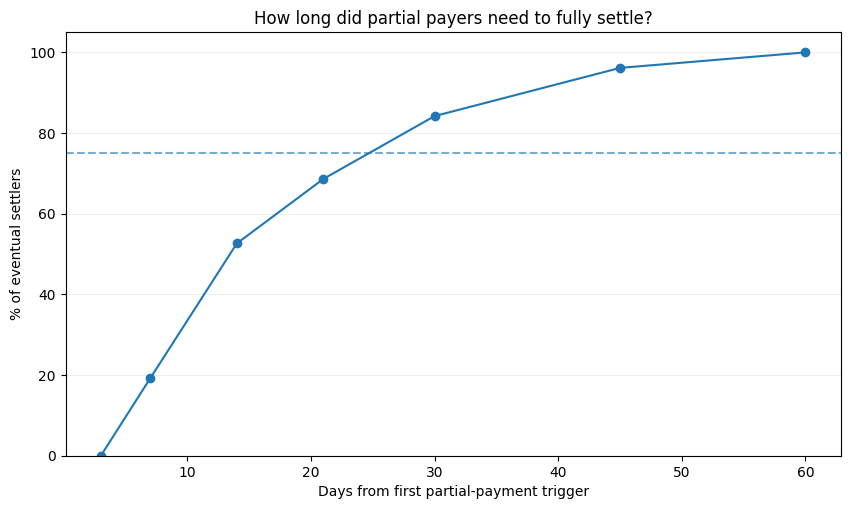

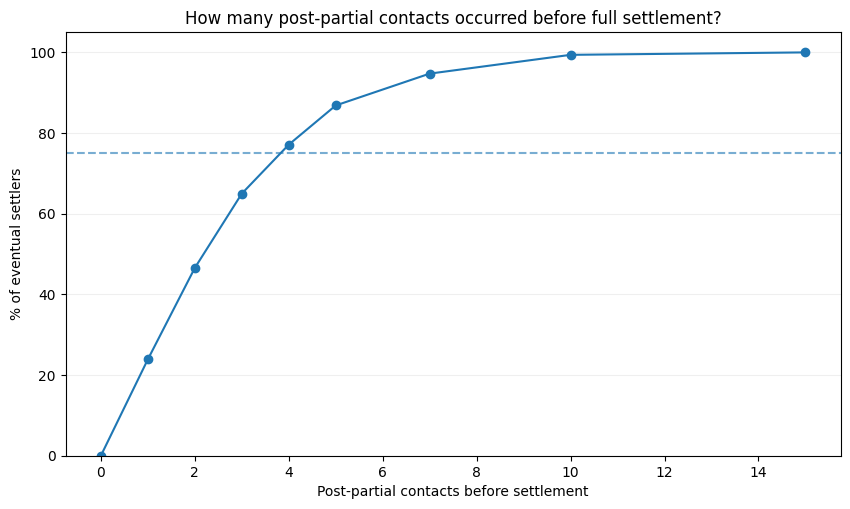


DATASETS CREATED
partial_completion_journey      : 1,746 customers
non_settled_pursuit_analysis    : 732 customers


In [13]:
# ============================================================
# PARTIAL PAYER — PAYMENT COMPLETION JOURNEY
#
# Objective:
#
# For customers whose FIRST observed payment was partial:
#
# 1. How long did eventual settlers need to fully settle?
# 2. How many post-partial contacts did they receive before settlement?
# 3. How persistent was the collection journey?
# 4. Among customers who did NOT settle:
#       - how many contacts did they receive?
#       - for how many days were they pursued?
#       - did the journey stop earlier than what successful
#         settlers historically needed?
#
# IMPORTANT
# ------------------------------------------------------------
# We do NOT know exact payment timestamps.
#
# "Settlement time" below = timestamp of the MESSAGE whose
# 72h response window contains the observed full settlement.
#
# Therefore:
# days_to_full_settlement_response is a journey proxy,
# NOT exact days to payment.
#
# Contact benchmarks are DESCRIPTIVE, not causal thresholds.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. CHECK REQUIRED OBJECTS
# ============================================================

required_objects = [
    "df",
    "first_partial",
    "payment_rows"
]

missing = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing:
    raise NameError(
        "Missing required objects: "
        + ", ".join(missing)
        + ". Execute the previous self-contained partial-payment "
          "analysis cell first."
    )


# ============================================================
# 1. PREPARE FIRST-PARTIAL BASE
# ============================================================

journey = first_partial[
    [
        "customer_id",
        "first_partial_trigger_sent_at",
        "post_partial_anchor",
        "dpd_at_first_partial",
        "balance_at_first_partial_brl",
        "first_partial_amount_brl",
        "remaining_after_first_partial_brl",
        "first_partial_pct_of_balance",
        "days_observable_after_partial"
    ]
].copy()

journey[
    "first_partial_trigger_sent_at"
] = pd.to_datetime(
    journey["first_partial_trigger_sent_at"]
)

journey["post_partial_anchor"] = pd.to_datetime(
    journey["post_partial_anchor"]
)


# ============================================================
# 2. FIND FIRST OBSERVED FULL SETTLEMENT RESPONSE
# AFTER FIRST PARTIAL
# ============================================================

future_full = (
    payment_rows.loc[
        payment_rows["payment_type"]
        == "FULL_SETTLEMENT",
        [
            "customer_id",
            "sent_at",
            "message_id",
            "template",
            "days_past_due",
            "amount_paid_brl"
        ]
    ]
    .merge(
        journey[
            [
                "customer_id",
                "first_partial_trigger_sent_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

future_full = (
    future_full.loc[
        future_full["sent_at"]
        >
        future_full[
            "first_partial_trigger_sent_at"
        ]
    ]
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
    .copy()
)

future_full = future_full.rename(
    columns={
        "sent_at":
            "full_settlement_trigger_at",

        "template":
            "settlement_trigger_template",

        "days_past_due":
            "dpd_at_settlement_trigger",

        "amount_paid_brl":
            "settlement_payment_brl"
    }
)


# ============================================================
# 3. MERGE SETTLEMENT INTO JOURNEY
# ============================================================

journey = journey.merge(
    future_full[
        [
            "customer_id",
            "full_settlement_trigger_at",
            "settlement_trigger_template",
            "dpd_at_settlement_trigger",
            "settlement_payment_brl"
        ]
    ],
    on="customer_id",
    how="left"
)

journey["eventually_full_settled"] = (
    journey[
        "full_settlement_trigger_at"
    ].notna()
)


# ============================================================
# 4. TIME FROM FIRST PARTIAL TRIGGER TO
# FULL SETTLEMENT RESPONSE TRIGGER
# ============================================================

journey[
    "days_to_full_settlement_response"
] = (
    (
        journey[
            "full_settlement_trigger_at"
        ]
        -
        journey[
            "first_partial_trigger_sent_at"
        ]
    )
    .dt.total_seconds()
    / 86400
)


# ============================================================
# 5. BUILD MESSAGE JOURNEY AFTER FIRST PARTIAL
# ============================================================

message_journey = (
    df[
        [
            "customer_id",
            "message_id",
            "sent_at",
            "template",
            "days_past_due"
        ]
    ]
    .merge(
        journey[
            [
                "customer_id",
                "first_partial_trigger_sent_at",
                "post_partial_anchor",
                "full_settlement_trigger_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

# Conservative:
# only communications definitely after the first payment window
message_journey = (
    message_journey.loc[
        message_journey["sent_at"]
        >
        message_journey["post_partial_anchor"]
    ]
    .copy()
)

message_journey[
    "days_after_partial_anchor"
] = (
    (
        message_journey["sent_at"]
        -
        message_journey["post_partial_anchor"]
    )
    .dt.total_seconds()
    / 86400
)


# ============================================================
# 6. CONTACTS BEFORE FULL SETTLEMENT
#
# For settlers:
# count communications after partial anchor and
# up to / including settlement-trigger message.
#
# For non-settlers:
# count all observed post-partial communications.
# ============================================================

message_journey[
    "contact_before_or_at_settlement"
] = np.where(
    message_journey[
        "full_settlement_trigger_at"
    ].notna(),

    message_journey["sent_at"]
    <=
    message_journey[
        "full_settlement_trigger_at"
    ],

    True
)

relevant_contacts = (
    message_journey.loc[
        message_journey[
            "contact_before_or_at_settlement"
        ]
    ]
    .copy()
)


contact_summary = (
    relevant_contacts
    .groupby("customer_id")
    .agg(
        n_contacts_after_partial=(
            "message_id",
            "count"
        ),

        first_contact_after_partial=(
            "sent_at",
            "min"
        ),

        last_relevant_contact=(
            "sent_at",
            "max"
        ),

        n_distinct_contact_days=(
            "sent_at",
            lambda x:
                x.dt.date.nunique()
        ),

        n_distinct_templates=(
            "template",
            "nunique"
        )
    )
    .reset_index()
)

journey = journey.merge(
    contact_summary,
    on="customer_id",
    how="left"
)

journey[
    "n_contacts_after_partial"
] = (
    journey[
        "n_contacts_after_partial"
    ]
    .fillna(0)
    .astype(int)
)

journey[
    "n_distinct_contact_days"
] = (
    journey[
        "n_distinct_contact_days"
    ]
    .fillna(0)
    .astype(int)
)

journey[
    "n_distinct_templates"
] = (
    journey[
        "n_distinct_templates"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 7. DAYS UNDER ACTIVE CONTACT
#
# Settled:
# partial anchor -> settlement trigger
#
# Not settled:
# partial anchor -> last observed post-partial contact
# ============================================================

journey[
    "days_until_last_contact"
] = (
    (
        journey[
            "last_relevant_contact"
        ]
        -
        journey[
            "post_partial_anchor"
        ]
    )
    .dt.total_seconds()
    / 86400
)

journey[
    "days_until_last_contact"
] = (
    journey[
        "days_until_last_contact"
    ]
    .clip(lower=0)
)


# ============================================================
# 8. SETTLED POPULATION
# ============================================================

settled = (
    journey.loc[
        journey[
            "eventually_full_settled"
        ]
    ]
    .copy()
)

not_settled = (
    journey.loc[
        ~journey[
            "eventually_full_settled"
        ]
    ]
    .copy()
)

print()
print("=" * 105)
print("PARTIAL PAYER — COMPLETION JOURNEY")
print("=" * 105)

print(
    f"Partial payers              : "
    f"{len(journey):,}"
)

print(
    f"Eventually full settled     : "
    f"{len(settled):,} "
    f"({len(settled)/len(journey)*100:.1f}%)"
)

print(
    f"Not full settled observed   : "
    f"{len(not_settled):,} "
    f"({len(not_settled)/len(journey)*100:.1f}%)"
)


# ============================================================
# 9. HOW LONG DID SETTLERS NEED?
# ============================================================

time_quantiles = (
    settled[
        "days_to_full_settlement_response"
    ]
    .quantile(
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
)

time_table = pd.DataFrame(
    {
        "percentile": [
            "P10",
            "P25",
            "P50 / Median",
            "P75",
            "P90"
        ],

        "days_to_full_settlement_response":
            time_quantiles.values
    }
)

print()
print("=" * 105)
print("TIME NEEDED TO REACH FULL SETTLEMENT")
print("Among partial payers who eventually settled")
print("=" * 105)

display(
    time_table.style.format(
        {
            "days_to_full_settlement_response":
                "{:.1f} days"
        }
    )
)


# ============================================================
# 10. HOW MANY CONTACTS DID SETTLERS RECEIVE?
# ============================================================

contact_quantiles = (
    settled[
        "n_contacts_after_partial"
    ]
    .quantile(
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
)

contact_table = pd.DataFrame(
    {
        "percentile": [
            "P10",
            "P25",
            "P50 / Median",
            "P75",
            "P90"
        ],

        "contacts_until_settlement":
            contact_quantiles.values
    }
)

print()
print("=" * 105)
print("CONTACTS NEEDED BEFORE FULL SETTLEMENT")
print("Among partial payers who eventually settled")
print("=" * 105)

display(
    contact_table.style.format(
        {
            "contacts_until_settlement":
                "{:.1f}"
        }
    )
)


# ============================================================
# 11. DISTINCT CONTACT DAYS NEEDED
# ============================================================

contact_day_quantiles = (
    settled[
        "n_distinct_contact_days"
    ]
    .quantile(
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
)

contact_day_table = pd.DataFrame(
    {
        "percentile": [
            "P10",
            "P25",
            "P50 / Median",
            "P75",
            "P90"
        ],

        "distinct_contact_days":
            contact_day_quantiles.values
    }
)

print()
print("=" * 105)
print("DISTINCT CONTACT DAYS BEFORE SETTLEMENT")
print("=" * 105)

display(
    contact_day_table.style.format(
        {
            "distinct_contact_days":
                "{:.1f}"
        }
    )
)


# ============================================================
# 12. CUMULATIVE SETTLEMENT BY TIME
# ============================================================

time_windows = [
    3,
    7,
    14,
    21,
    30,
    45,
    60
]

cumulative_time = []

for days in time_windows:

    n = (
        settled[
            "days_to_full_settlement_response"
        ]
        <= days
    ).sum()

    cumulative_time.append(
        {
            "within_days": days,
            "settled_customers": n,
            "pct_of_eventual_settlers":
                n / len(settled) * 100
        }
    )

cumulative_time = pd.DataFrame(
    cumulative_time
)

print()
print("=" * 105)
print("CUMULATIVE SETTLEMENT — TIME")
print("=" * 105)

display(
    cumulative_time.style.format(
        {
            "settled_customers":
                "{:,.0f}",

            "pct_of_eventual_settlers":
                "{:.1f}%"
        }
    )
)


# ============================================================
# 13. CUMULATIVE SETTLEMENT BY NUMBER OF CONTACTS
# ============================================================

contact_windows = [
    0,
    1,
    2,
    3,
    4,
    5,
    7,
    10,
    15
]

cumulative_contacts = []

for n_contacts in contact_windows:

    n = (
        settled[
            "n_contacts_after_partial"
        ]
        <= n_contacts
    ).sum()

    cumulative_contacts.append(
        {
            "contacts_or_fewer":
                n_contacts,

            "settled_customers":
                n,

            "pct_of_eventual_settlers":
                n / len(settled) * 100
        }
    )

cumulative_contacts = pd.DataFrame(
    cumulative_contacts
)

print()
print("=" * 105)
print("CUMULATIVE SETTLEMENT — NUMBER OF CONTACTS")
print("=" * 105)

display(
    cumulative_contacts.style.format(
        {
            "settled_customers":
                "{:,.0f}",

            "pct_of_eventual_settlers":
                "{:.1f}%"
        }
    )
)


# ============================================================
# 14. SETTLED vs NOT SETTLED — CONTACT JOURNEY
#
# IMPORTANT:
# not-settled customers can be censored.
# We therefore show observability explicitly.
# ============================================================

journey_comparison = (
    journey
    .assign(
        settlement_group=np.where(
            journey[
                "eventually_full_settled"
            ],
            "EVENTUALLY SETTLED",
            "NOT SETTLED"
        )
    )
    .groupby(
        "settlement_group"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        median_dpd_at_partial=(
            "dpd_at_first_partial",
            "median"
        ),

        median_partial_pct=(
            "first_partial_pct_of_balance",
            "median"
        ),

        median_residual_balance=(
            "remaining_after_first_partial_brl",
            "median"
        ),

        mean_contacts=(
            "n_contacts_after_partial",
            "mean"
        ),

        median_contacts=(
            "n_contacts_after_partial",
            "median"
        ),

        p75_contacts=(
            "n_contacts_after_partial",
            lambda x:
                x.quantile(.75)
        ),

        median_contact_days=(
            "n_distinct_contact_days",
            "median"
        ),

        median_days_until_last_contact=(
            "days_until_last_contact",
            "median"
        ),

        median_observable_days=(
            "days_observable_after_partial",
            "median"
        )
    )
    .reset_index()
)

print()
print("=" * 105)
print("SETTLED vs NOT SETTLED — COLLECTION JOURNEY")
print("=" * 105)

display(
    journey_comparison.style.format(
        {
            "customers":
                "{:,.0f}",

            "median_dpd_at_partial":
                "{:.1f}",

            "median_partial_pct":
                "{:.1%}",

            "median_residual_balance":
                "R$ {:,.2f}",

            "mean_contacts":
                "{:.2f}",

            "median_contacts":
                "{:.1f}",

            "p75_contacts":
                "{:.1f}",

            "median_contact_days":
                "{:.1f}",

            "median_days_until_last_contact":
                "{:.1f}",

            "median_observable_days":
                "{:.1f}"
        }
    )
)


# ============================================================
# 15. BENCHMARKS FROM SUCCESSFUL SETTLERS
#
# These are descriptive benchmarks.
#
# P75 TIME:
# 75% of eventual settlers reached settlement by this time.
#
# P75 CONTACTS:
# 75% of eventual settlers had this many or fewer contacts.
# ============================================================

TIME_BENCHMARK_P75 = (
    settled[
        "days_to_full_settlement_response"
    ]
    .quantile(.75)
)

CONTACT_BENCHMARK_P75 = (
    settled[
        "n_contacts_after_partial"
    ]
    .quantile(.75)
)

CONTACT_BENCHMARK_MEDIAN = (
    settled[
        "n_contacts_after_partial"
    ]
    .median()
)

print()
print("=" * 105)
print("SUCCESSFUL-JOURNEY BENCHMARKS")
print("=" * 105)

print(
    f"P75 time to settlement response : "
    f"{TIME_BENCHMARK_P75:.1f} days"
)

print(
    f"Median contacts until settlement: "
    f"{CONTACT_BENCHMARK_MEDIAN:.1f}"
)

print(
    f"P75 contacts until settlement   : "
    f"{CONTACT_BENCHMARK_P75:.1f}"
)


# ============================================================
# 16. NON-SETTLED WITH ENOUGH OBSERVATION
#
# Only compare customers who had at least the P75 settlement
# time available in the dataset.
#
# This avoids labeling late-August customers as under-pursued.
# ============================================================

not_settled_mature = (
    not_settled.loc[
        not_settled[
            "days_observable_after_partial"
        ]
        >= TIME_BENCHMARK_P75
    ]
    .copy()
)


# ============================================================
# 17. DESCRIPTIVE PURSUIT SEGMENTS
#
# IMPORTANT:
# These labels describe contact intensity relative to
# successful journeys.
#
# They do NOT imply that more contacts would have caused
# settlement.
# ============================================================

not_settled_mature[
    "pursuit_segment"
] = np.select(
    [
        not_settled_mature[
            "n_contacts_after_partial"
        ] == 0,

        not_settled_mature[
            "n_contacts_after_partial"
        ]
        < CONTACT_BENCHMARK_MEDIAN,

        not_settled_mature[
            "n_contacts_after_partial"
        ]
        < CONTACT_BENCHMARK_P75
    ],

    [
        "NO POST-PARTIAL CONTACT",

        "BELOW SETTLER MEDIAN",

        "BETWEEN SETTLER MEDIAN AND P75"
    ],

    default=
        "AT / ABOVE SETTLER P75"
)


pursuit_summary = (
    not_settled_mature
    .groupby(
        "pursuit_segment"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        ),

        median_contacts=(
            "n_contacts_after_partial",
            "median"
        ),

        median_contact_days=(
            "n_distinct_contact_days",
            "median"
        ),

        median_days_until_last_contact=(
            "days_until_last_contact",
            "median"
        ),

        median_dpd=(
            "dpd_at_first_partial",
            "median"
        )
    )
    .reset_index()
)

pursuit_summary["pct_customers"] = (
    pursuit_summary["customers"]
    / pursuit_summary["customers"].sum()
    * 100
)

pursuit_summary[
    "pct_residual_balance"
] = (
    pursuit_summary[
        "residual_balance_brl"
    ]
    / pursuit_summary[
        "residual_balance_brl"
    ].sum()
    * 100
)

print()
print("=" * 105)
print("NON-SETTLED PARTIAL PAYERS — PURSUIT INTENSITY")
print(
    f"Only customers with >= "
    f"{TIME_BENCHMARK_P75:.1f} observable days"
)
print("=" * 105)

display(
    pursuit_summary.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "pct_residual_balance":
                "{:.1f}%",

            "median_contacts":
                "{:.1f}",

            "median_contact_days":
                "{:.1f}",

            "median_days_until_last_contact":
                "{:.1f}",

            "median_dpd":
                "{:.1f}"
        }
    )
)


# ============================================================
# 18. CONTACT COUNT DISTRIBUTION — NON-SETTLED MATURE
# ============================================================

contact_bins = [
    -0.1,
    0.5,
    1.5,
    2.5,
    3.5,
    5.5,
    10.5,
    np.inf
]

contact_labels = [
    "0",
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11+"
]

not_settled_mature[
    "contact_count_bucket"
] = pd.cut(
    not_settled_mature[
        "n_contacts_after_partial"
    ],
    bins=contact_bins,
    labels=contact_labels
)

contact_distribution = (
    not_settled_mature
    .groupby(
        "contact_count_bucket",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        residual_balance_brl=(
            "remaining_after_first_partial_brl",
            "sum"
        )
    )
    .reset_index()
)

contact_distribution["pct_customers"] = (
    contact_distribution["customers"]
    / contact_distribution["customers"].sum()
    * 100
)

print()
print("=" * 105)
print("NOT SETTLED — POST-PARTIAL CONTACT DISTRIBUTION")
print("=" * 105)

display(
    contact_distribution.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 19. GRAPH 1 — CUMULATIVE SETTLEMENT BY TIME
# ============================================================

plt.figure(
    figsize=(10, 5.5)
)

plt.plot(
    cumulative_time["within_days"],
    cumulative_time[
        "pct_of_eventual_settlers"
    ],
    marker="o"
)

plt.axhline(
    75,
    linestyle="--",
    alpha=0.6
)

plt.xlabel(
    "Days from first partial-payment trigger"
)

plt.ylabel(
    "% of eventual settlers"
)

plt.title(
    "How long did partial payers need to fully settle?"
)

plt.ylim(
    0,
    105
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


# ============================================================
# 20. GRAPH 2 — CUMULATIVE SETTLEMENT BY CONTACTS
# ============================================================

plt.figure(
    figsize=(10, 5.5)
)

plt.plot(
    cumulative_contacts[
        "contacts_or_fewer"
    ],
    cumulative_contacts[
        "pct_of_eventual_settlers"
    ],
    marker="o"
)

plt.axhline(
    75,
    linestyle="--",
    alpha=0.6
)

plt.xlabel(
    "Post-partial contacts before settlement"
)

plt.ylabel(
    "% of eventual settlers"
)

plt.title(
    "How many post-partial contacts occurred before full settlement?"
)

plt.ylim(
    0,
    105
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


# ============================================================
# 21. SAVE DATASETS FOR NEXT ANALYSIS
# ============================================================

partial_completion_journey = (
    journey.copy()
)

non_settled_pursuit_analysis = (
    not_settled_mature.copy()
)

print()
print("=" * 105)
print("DATASETS CREATED")
print("=" * 105)

print(
    "partial_completion_journey      : "
    f"{len(partial_completion_journey):,} customers"
)

print(
    "non_settled_pursuit_analysis    : "
    f"{len(non_settled_pursuit_analysis):,} customers"
)


GROUP A — PARTIAL PAYMENT, NOT SETTLED
Only customers with enough calendar time to reach DPD60
Eligible customers: 474


,journey_status,customers,residual_balance_brl,median_last_dpd,median_post_partial_messages,pct_customers
0,REACHED DPD60,32,"R$ 13,962.55",60.0,5.5,6.8%
1,STOPPED BEFORE DPD60,442,"R$ 180,582.99",52.5,5.0,93.2%



GROUP B — NO PAYMENT
Only customers with enough calendar time to reach DPD60
Eligible customers: 2,211


,journey_status,customers,outstanding_balance_brl,median_max_dpd,median_messages,pct_customers
0,REACHED DPD60,202,"R$ 168,994.91",60.0,11.0,9.1%
1,STOPPED BEFORE DPD60,"2,009","R$ 1,738,600.03",53.0,10.0,90.9%



EXECUTIVE COMPARISON


,group,customers,pct_of_eligible_group,balance_brl
0,PARTIAL PAYER — stopped before DPD60,442,93.2%,"R$ 180,582.99"
1,NO PAYER — pursued to DPD60,202,9.1%,"R$ 168,994.91"


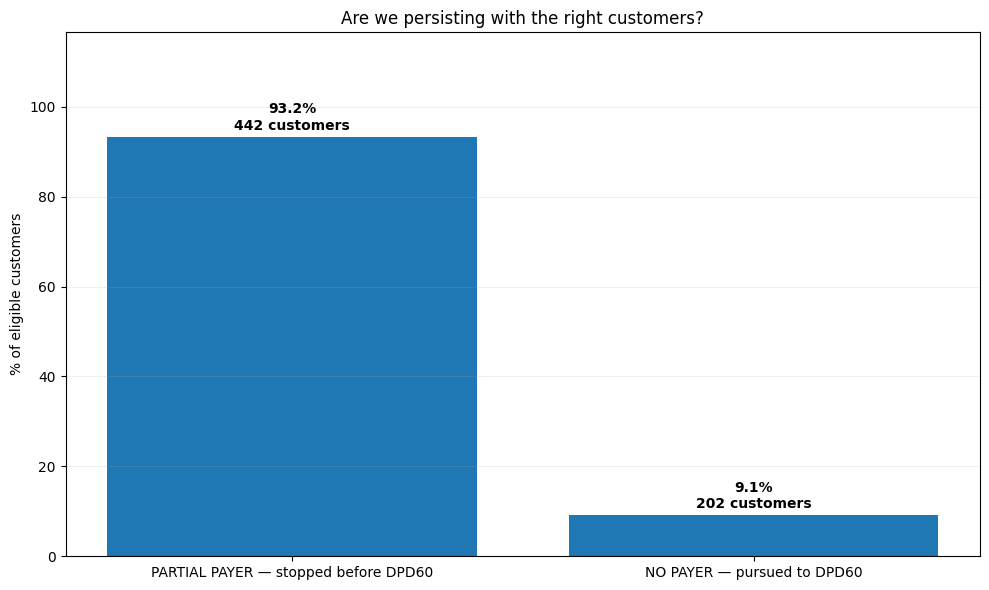


DATASETS CREATED
partial_not_settled_dpd60 : 474
no_payer_dpd60            : 2,211


In [15]:
# ============================================================
# COLLECTION EFFORT ALLOCATION
# PARTIAL PAYER vs NO PAYER
#
# Business question:
#
# Are we stopping the collection journey early for customers
# who demonstrated payment intent (partial payment), while
# continuing to spend collection effort on customers who
# never paid until the end of the DPD 60 journey?
#
# CUSTOMER GRAIN
#
# GROUP A:
#   PARTIAL PAYER + NOT FULLY SETTLED
#   -> did collection stop before DPD 60?
#
# GROUP B:
#   NO PAYMENT OBSERVED
#   -> was customer pursued until DPD 60?
#
# IMPORTANT:
# Only customers with enough observable calendar time to
# potentially reach DPD 60 are used for the "stopped early"
# comparison.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. PREPARE DATA
# ============================================================

x = df.copy()

x["sent_at"] = pd.to_datetime(x["sent_at"])

for col in [
    "days_past_due",
    "outstanding_balance_brl",
    "amount_paid_brl",
    "paid_within_72h"
]:
    x[col] = pd.to_numeric(
        x[col],
        errors="coerce"
    )

DATA_END = x["sent_at"].max()

TOL = 0.05
DPD_END = 60


# ============================================================
# 1. PAYMENT RESPONSE
# ============================================================

x["payment_response"] = (
    x["paid_within_72h"].fillna(0).eq(1)
    &
    x["amount_paid_brl"].fillna(0).gt(TOL)
)

x["discount_flag"] = (
    x["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

x["settlement_threshold_brl"] = np.where(
    x["discount_flag"],
    0.85 * x["outstanding_balance_brl"],
    x["outstanding_balance_brl"]
)

x["payment_type"] = np.where(
    ~x["payment_response"],
    "NO_PAYMENT_RESPONSE",
    np.where(
        x["amount_paid_brl"]
        >= x["settlement_threshold_brl"] - TOL,
        "FULL_SETTLEMENT",
        "PARTIAL_PAYMENT"
    )
)


# ============================================================
# 2. CUSTOMER-LEVEL PAYMENT HISTORY
# ============================================================

payment_customer = (
    x.groupby("customer_id")
    .agg(
        any_payment=(
            "payment_response",
            "max"
        ),

        any_partial=(
            "payment_type",
            lambda s:
                (s == "PARTIAL_PAYMENT").any()
        ),

        any_full=(
            "payment_type",
            lambda s:
                (s == "FULL_SETTLEMENT").any()
        ),

        first_observed_at=(
            "sent_at",
            "min"
        ),

        last_observed_at=(
            "sent_at",
            "max"
        ),

        first_dpd=(
            "days_past_due",
            "min"
        ),

        max_observed_dpd=(
            "days_past_due",
            "max"
        ),

        total_messages=(
            "message_id",
            "count"
        )
    )
    .reset_index()
)


# ============================================================
# 3. FIRST PARTIAL PAYMENT PER CUSTOMER
# ============================================================

first_partial = (
    x.loc[
        x["payment_type"]
        == "PARTIAL_PAYMENT"
    ]
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
    [
        [
            "customer_id",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "first_partial_at",

            "days_past_due":
                "dpd_at_first_partial",

            "outstanding_balance_brl":
                "balance_at_first_partial",

            "amount_paid_brl":
                "first_partial_amount"
        }
    )
)

first_partial[
    "residual_after_first_partial"
] = (
    first_partial[
        "balance_at_first_partial"
    ]
    -
    first_partial[
        "first_partial_amount"
    ]
).clip(lower=0)


# ============================================================
# 4. IDENTIFY FULL SETTLEMENT AFTER FIRST PARTIAL
# ============================================================

full_rows = (
    x.loc[
        x["payment_type"]
        == "FULL_SETTLEMENT",
        [
            "customer_id",
            "sent_at",
            "days_past_due"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "full_at",

            "days_past_due":
                "full_dpd"
        }
    )
)

partial_base = (
    first_partial
    .merge(
        payment_customer,
        on="customer_id",
        how="left"
    )
)

future_full = (
    full_rows
    .merge(
        first_partial[
            [
                "customer_id",
                "first_partial_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

future_full = (
    future_full.loc[
        future_full["full_at"]
        >
        future_full["first_partial_at"]
    ]
    .sort_values(
        [
            "customer_id",
            "full_at"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
)

partial_base = partial_base.merge(
    future_full[
        [
            "customer_id",
            "full_at",
            "full_dpd"
        ]
    ],
    on="customer_id",
    how="left"
)

partial_base[
    "eventually_settled"
] = (
    partial_base["full_at"].notna()
)


# ============================================================
# 5. PARTIAL PAYERS WHO DID NOT SETTLE
# ============================================================

partial_not_settled = (
    partial_base.loc[
        ~partial_base[
            "eventually_settled"
        ]
    ]
    .copy()
)


# ============================================================
# 6. CALCULATE WHETHER CUSTOMER HAD ENOUGH CALENDAR TIME
# TO REACH DPD 60
#
# If customer was DPD d at first partial,
# days needed to reach DPD60 = 60 - d
#
# We compare this with remaining observation time.
# ============================================================

partial_not_settled[
    "days_available_after_partial"
] = (
    (
        DATA_END
        -
        partial_not_settled[
            "first_partial_at"
        ]
    )
    .dt.total_seconds()
    / 86400
)

partial_not_settled[
    "days_needed_to_dpd60"
] = (
    DPD_END
    -
    partial_not_settled[
        "dpd_at_first_partial"
    ]
).clip(lower=0)

partial_not_settled[
    "had_time_to_reach_dpd60"
] = (
    partial_not_settled[
        "days_available_after_partial"
    ]
    >=
    partial_not_settled[
        "days_needed_to_dpd60"
    ]
)


# ============================================================
# 7. POST-PARTIAL CONTACT HISTORY
# ============================================================

post_partial = (
    x[
        [
            "customer_id",
            "message_id",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl",
            "template"
        ]
    ]
    .merge(
        partial_not_settled[
            [
                "customer_id",
                "first_partial_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

post_partial = (
    post_partial.loc[
        post_partial["sent_at"]
        >
        post_partial["first_partial_at"]
    ]
    .copy()
)

post_partial_summary = (
    post_partial
    .groupby("customer_id")
    .agg(
        post_partial_messages=(
            "message_id",
            "count"
        ),

        last_post_partial_contact=(
            "sent_at",
            "max"
        ),

        last_contact_dpd=(
            "days_past_due",
            "max"
        ),

        last_observed_balance=(
            "outstanding_balance_brl",
            "last"
        )
    )
    .reset_index()
)

partial_not_settled = (
    partial_not_settled
    .merge(
        post_partial_summary,
        on="customer_id",
        how="left"
    )
)

partial_not_settled[
    "post_partial_messages"
] = (
    partial_not_settled[
        "post_partial_messages"
    ]
    .fillna(0)
    .astype(int)
)

partial_not_settled[
    "last_contact_dpd"
] = (
    partial_not_settled[
        "last_contact_dpd"
    ]
    .fillna(
        partial_not_settled[
            "dpd_at_first_partial"
        ]
    )
)


# ============================================================
# 8. GROUP A:
# PARTIAL PAYER + NOT SETTLED + ENOUGH TIME TO REACH DPD60
# ============================================================

partial_mature = (
    partial_not_settled.loc[
        partial_not_settled[
            "had_time_to_reach_dpd60"
        ]
    ]
    .copy()
)

partial_mature[
    "journey_status"
] = np.where(
    partial_mature[
        "last_contact_dpd"
    ]
    >= DPD_END,

    "REACHED DPD60",

    "STOPPED BEFORE DPD60"
)


# ============================================================
# 9. NO-PAYERS
#
# No observed positive payment response anywhere in history.
# ============================================================

no_payers = (
    payment_customer.loc[
        ~payment_customer[
            "any_payment"
        ]
    ]
    .copy()
)


# ============================================================
# 10. NO-PAYER MATURITY
#
# Estimate whether they had enough calendar time to reach DPD60
# from first observed DPD.
# ============================================================

no_payers[
    "days_available"
] = (
    (
        DATA_END
        -
        no_payers[
            "first_observed_at"
        ]
    )
    .dt.total_seconds()
    / 86400
)

no_payers[
    "days_needed_to_dpd60"
] = (
    DPD_END
    -
    no_payers[
        "first_dpd"
    ]
).clip(lower=0)

no_payers[
    "had_time_to_reach_dpd60"
] = (
    no_payers[
        "days_available"
    ]
    >=
    no_payers[
        "days_needed_to_dpd60"
    ]
)

no_payers_mature = (
    no_payers.loc[
        no_payers[
            "had_time_to_reach_dpd60"
        ]
    ]
    .copy()
)

no_payers_mature[
    "journey_status"
] = np.where(
    no_payers_mature[
        "max_observed_dpd"
    ]
    >= DPD_END,

    "REACHED DPD60",

    "STOPPED BEFORE DPD60"
)


# ============================================================
# 11. SUMMARY — PARTIAL PAYERS
# ============================================================

partial_summary = (
    partial_mature
    .groupby(
        "journey_status"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        residual_balance_brl=(
            "residual_after_first_partial",
            "sum"
        ),

        median_last_dpd=(
            "last_contact_dpd",
            "median"
        ),

        median_post_partial_messages=(
            "post_partial_messages",
            "median"
        )
    )
    .reset_index()
)

partial_summary[
    "pct_customers"
] = (
    partial_summary[
        "customers"
    ]
    /
    partial_summary[
        "customers"
    ].sum()
    * 100
)


# ============================================================
# 12. SUMMARY — NO PAYERS
# ============================================================

# First observed balance for no-payers
first_customer_rows = (
    x.sort_values(
        [
            "customer_id",
            "sent_at"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
    [
        [
            "customer_id",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "outstanding_balance_brl":
                "initial_balance_brl"
        }
    )
)

no_payers_mature = (
    no_payers_mature
    .merge(
        first_customer_rows,
        on="customer_id",
        how="left"
    )
)

no_payer_summary = (
    no_payers_mature
    .groupby(
        "journey_status"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        outstanding_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        median_max_dpd=(
            "max_observed_dpd",
            "median"
        ),

        median_messages=(
            "total_messages",
            "median"
        )
    )
    .reset_index()
)

no_payer_summary[
    "pct_customers"
] = (
    no_payer_summary[
        "customers"
    ]
    /
    no_payer_summary[
        "customers"
    ].sum()
    * 100
)


# ============================================================
# 13. PRINT RESULTS
# ============================================================

print()
print("=" * 110)
print("GROUP A — PARTIAL PAYMENT, NOT SETTLED")
print("Only customers with enough calendar time to reach DPD60")
print("=" * 110)

print(
    f"Eligible customers: "
    f"{len(partial_mature):,}"
)

display(
    partial_summary.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "median_last_dpd":
                "{:.1f}",

            "median_post_partial_messages":
                "{:.1f}"
        }
    )
)


print()
print("=" * 110)
print("GROUP B — NO PAYMENT")
print("Only customers with enough calendar time to reach DPD60")
print("=" * 110)

print(
    f"Eligible customers: "
    f"{len(no_payers_mature):,}"
)

display(
    no_payer_summary.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "outstanding_balance_brl":
                "R$ {:,.2f}",

            "median_max_dpd":
                "{:.1f}",

            "median_messages":
                "{:.1f}"
        }
    )
)


# ============================================================
# 14. EXECUTIVE COMPARISON
#
# What we specifically want:
#
# Partial payers:
# % STOPPED BEFORE DPD60
#
# No payers:
# % REACHED DPD60
# ============================================================

partial_stopped = (
    partial_mature[
        "journey_status"
    ]
    .eq(
        "STOPPED BEFORE DPD60"
    )
)

no_payer_reached = (
    no_payers_mature[
        "journey_status"
    ]
    .eq(
        "REACHED DPD60"
    )
)

partial_stopped_n = (
    partial_stopped.sum()
)

no_payer_reached_n = (
    no_payer_reached.sum()
)

partial_stopped_pct = (
    partial_stopped.mean()
    * 100
)

no_payer_reached_pct = (
    no_payer_reached.mean()
    * 100
)

partial_stopped_balance = (
    partial_mature.loc[
        partial_stopped,
        "residual_after_first_partial"
    ]
    .sum()
)

no_payer_reached_balance = (
    no_payers_mature.loc[
        no_payer_reached,
        "initial_balance_brl"
    ]
    .sum()
)


executive_comparison = pd.DataFrame(
    {
        "group": [
            "PARTIAL PAYER — stopped before DPD60",
            "NO PAYER — pursued to DPD60"
        ],

        "customers": [
            partial_stopped_n,
            no_payer_reached_n
        ],

        "pct_of_eligible_group": [
            partial_stopped_pct,
            no_payer_reached_pct
        ],

        "balance_brl": [
            partial_stopped_balance,
            no_payer_reached_balance
        ]
    }
)

print()
print("=" * 110)
print("EXECUTIVE COMPARISON")
print("=" * 110)

display(
    executive_comparison.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_of_eligible_group":
                "{:.1f}%",

            "balance_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 15. VISUAL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    executive_comparison["group"],
    executive_comparison[
        "pct_of_eligible_group"
    ]
)

plt.ylabel(
    "% of eligible customers"
)

plt.title(
    "Are we persisting with the right customers?"
)

plt.ylim(
    0,
    max(
        executive_comparison[
            "pct_of_eligible_group"
        ].max() * 1.25,
        10
    )
)

for bar, pct, n in zip(
    bars,
    executive_comparison[
        "pct_of_eligible_group"
    ],
    executive_comparison[
        "customers"
    ]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 1,

        f"{pct:.1f}%\n{n:,.0f} customers",

        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DATASETS FOR DRILL-DOWN
# ============================================================

partial_not_settled_dpd60 = (
    partial_mature.copy()
)

no_payer_dpd60 = (
    no_payers_mature.copy()
)

print()
print("=" * 110)
print("DATASETS CREATED")
print("=" * 110)

print(
    "partial_not_settled_dpd60 : "
    f"{len(partial_not_settled_dpd60):,}"
)

print(
    "no_payer_dpd60            : "
    f"{len(no_payer_dpd60):,}"
)


GROUP A — PARTIAL PAYMENT, NOT SETTLED
Only customers with enough calendar time to reach DPD60
Eligible customers: 474


,journey_status,customers,residual_balance_brl,median_last_dpd,median_post_partial_messages,pct_customers
0,REACHED DPD60,32,"R$ 13,962.55",60.0,5.5,6.8%
1,STOPPED BEFORE DPD60,442,"R$ 180,582.99",52.5,5.0,93.2%



GROUP B — NO PAYMENT
Only customers with enough calendar time to reach DPD60
Eligible customers: 2,211


,journey_status,customers,outstanding_balance_brl,median_max_dpd,median_messages,pct_customers
0,REACHED DPD60,202,"R$ 168,994.91",60.0,11.0,9.1%
1,STOPPED BEFORE DPD60,"2,009","R$ 1,738,600.03",53.0,10.0,90.9%



EXECUTIVE COMPARISON


,group,customers,pct_of_eligible_group,balance_brl
0,PARTIAL PAYER — stopped before DPD60,442,93.2%,"R$ 180,582.99"
1,NO PAYER — pursued to DPD60,202,9.1%,"R$ 168,994.91"


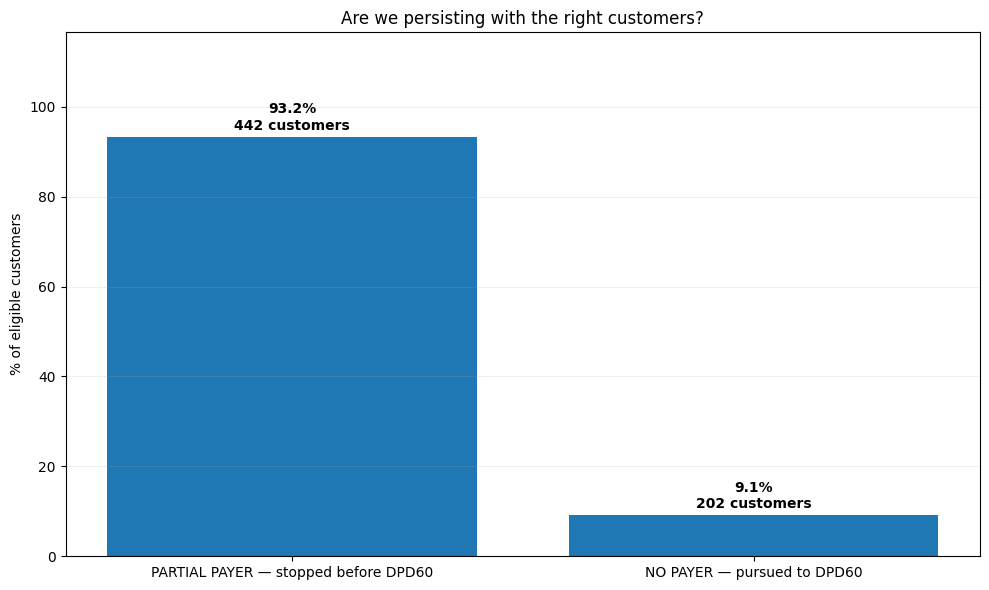


DATASETS CREATED
partial_not_settled_dpd60 : 474
no_payer_dpd60            : 2,211


In [16]:
# ============================================================
# COLLECTION EFFORT ALLOCATION
# PARTIAL PAYER vs NO PAYER
#
# Business question:
#
# Are we stopping the collection journey early for customers
# who demonstrated payment intent (partial payment), while
# continuing to spend collection effort on customers who
# never paid until the end of the DPD 60 journey?
#
# CUSTOMER GRAIN
#
# GROUP A:
#   PARTIAL PAYER + NOT FULLY SETTLED
#   -> did collection stop before DPD 60?
#
# GROUP B:
#   NO PAYMENT OBSERVED
#   -> was customer pursued until DPD 60?
#
# IMPORTANT:
# Only customers with enough observable calendar time to
# potentially reach DPD 60 are used for the "stopped early"
# comparison.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0. PREPARE DATA
# ============================================================

x = df.copy()

x["sent_at"] = pd.to_datetime(x["sent_at"])

for col in [
    "days_past_due",
    "outstanding_balance_brl",
    "amount_paid_brl",
    "paid_within_72h"
]:
    x[col] = pd.to_numeric(
        x[col],
        errors="coerce"
    )

DATA_END = x["sent_at"].max()

TOL = 0.05
DPD_END = 60


# ============================================================
# 1. PAYMENT RESPONSE
# ============================================================

x["payment_response"] = (
    x["paid_within_72h"].fillna(0).eq(1)
    &
    x["amount_paid_brl"].fillna(0).gt(TOL)
)

x["discount_flag"] = (
    x["template"]
    .astype(str)
    .str.contains(
        "discount_offer",
        case=False,
        na=False
    )
)

x["settlement_threshold_brl"] = np.where(
    x["discount_flag"],
    0.85 * x["outstanding_balance_brl"],
    x["outstanding_balance_brl"]
)

x["payment_type"] = np.where(
    ~x["payment_response"],
    "NO_PAYMENT_RESPONSE",
    np.where(
        x["amount_paid_brl"]
        >= x["settlement_threshold_brl"] - TOL,
        "FULL_SETTLEMENT",
        "PARTIAL_PAYMENT"
    )
)


# ============================================================
# 2. CUSTOMER-LEVEL PAYMENT HISTORY
# ============================================================

payment_customer = (
    x.groupby("customer_id")
    .agg(
        any_payment=(
            "payment_response",
            "max"
        ),

        any_partial=(
            "payment_type",
            lambda s:
                (s == "PARTIAL_PAYMENT").any()
        ),

        any_full=(
            "payment_type",
            lambda s:
                (s == "FULL_SETTLEMENT").any()
        ),

        first_observed_at=(
            "sent_at",
            "min"
        ),

        last_observed_at=(
            "sent_at",
            "max"
        ),

        first_dpd=(
            "days_past_due",
            "min"
        ),

        max_observed_dpd=(
            "days_past_due",
            "max"
        ),

        total_messages=(
            "message_id",
            "count"
        )
    )
    .reset_index()
)


# ============================================================
# 3. FIRST PARTIAL PAYMENT PER CUSTOMER
# ============================================================

first_partial = (
    x.loc[
        x["payment_type"]
        == "PARTIAL_PAYMENT"
    ]
    .sort_values(
        [
            "customer_id",
            "sent_at",
            "message_id"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
    [
        [
            "customer_id",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl",
            "amount_paid_brl"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "first_partial_at",

            "days_past_due":
                "dpd_at_first_partial",

            "outstanding_balance_brl":
                "balance_at_first_partial",

            "amount_paid_brl":
                "first_partial_amount"
        }
    )
)

first_partial[
    "residual_after_first_partial"
] = (
    first_partial[
        "balance_at_first_partial"
    ]
    -
    first_partial[
        "first_partial_amount"
    ]
).clip(lower=0)


# ============================================================
# 4. IDENTIFY FULL SETTLEMENT AFTER FIRST PARTIAL
# ============================================================

full_rows = (
    x.loc[
        x["payment_type"]
        == "FULL_SETTLEMENT",
        [
            "customer_id",
            "sent_at",
            "days_past_due"
        ]
    ]
    .rename(
        columns={
            "sent_at":
                "full_at",

            "days_past_due":
                "full_dpd"
        }
    )
)

partial_base = (
    first_partial
    .merge(
        payment_customer,
        on="customer_id",
        how="left"
    )
)

future_full = (
    full_rows
    .merge(
        first_partial[
            [
                "customer_id",
                "first_partial_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

future_full = (
    future_full.loc[
        future_full["full_at"]
        >
        future_full["first_partial_at"]
    ]
    .sort_values(
        [
            "customer_id",
            "full_at"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
)

partial_base = partial_base.merge(
    future_full[
        [
            "customer_id",
            "full_at",
            "full_dpd"
        ]
    ],
    on="customer_id",
    how="left"
)

partial_base[
    "eventually_settled"
] = (
    partial_base["full_at"].notna()
)


# ============================================================
# 5. PARTIAL PAYERS WHO DID NOT SETTLE
# ============================================================

partial_not_settled = (
    partial_base.loc[
        ~partial_base[
            "eventually_settled"
        ]
    ]
    .copy()
)


# ============================================================
# 6. CALCULATE WHETHER CUSTOMER HAD ENOUGH CALENDAR TIME
# TO REACH DPD 60
#
# If customer was DPD d at first partial,
# days needed to reach DPD60 = 60 - d
#
# We compare this with remaining observation time.
# ============================================================

partial_not_settled[
    "days_available_after_partial"
] = (
    (
        DATA_END
        -
        partial_not_settled[
            "first_partial_at"
        ]
    )
    .dt.total_seconds()
    / 86400
)

partial_not_settled[
    "days_needed_to_dpd60"
] = (
    DPD_END
    -
    partial_not_settled[
        "dpd_at_first_partial"
    ]
).clip(lower=0)

partial_not_settled[
    "had_time_to_reach_dpd60"
] = (
    partial_not_settled[
        "days_available_after_partial"
    ]
    >=
    partial_not_settled[
        "days_needed_to_dpd60"
    ]
)


# ============================================================
# 7. POST-PARTIAL CONTACT HISTORY
# ============================================================

post_partial = (
    x[
        [
            "customer_id",
            "message_id",
            "sent_at",
            "days_past_due",
            "outstanding_balance_brl",
            "template"
        ]
    ]
    .merge(
        partial_not_settled[
            [
                "customer_id",
                "first_partial_at"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

post_partial = (
    post_partial.loc[
        post_partial["sent_at"]
        >
        post_partial["first_partial_at"]
    ]
    .copy()
)

post_partial_summary = (
    post_partial
    .groupby("customer_id")
    .agg(
        post_partial_messages=(
            "message_id",
            "count"
        ),

        last_post_partial_contact=(
            "sent_at",
            "max"
        ),

        last_contact_dpd=(
            "days_past_due",
            "max"
        ),

        last_observed_balance=(
            "outstanding_balance_brl",
            "last"
        )
    )
    .reset_index()
)

partial_not_settled = (
    partial_not_settled
    .merge(
        post_partial_summary,
        on="customer_id",
        how="left"
    )
)

partial_not_settled[
    "post_partial_messages"
] = (
    partial_not_settled[
        "post_partial_messages"
    ]
    .fillna(0)
    .astype(int)
)

partial_not_settled[
    "last_contact_dpd"
] = (
    partial_not_settled[
        "last_contact_dpd"
    ]
    .fillna(
        partial_not_settled[
            "dpd_at_first_partial"
        ]
    )
)


# ============================================================
# 8. GROUP A:
# PARTIAL PAYER + NOT SETTLED + ENOUGH TIME TO REACH DPD60
# ============================================================

partial_mature = (
    partial_not_settled.loc[
        partial_not_settled[
            "had_time_to_reach_dpd60"
        ]
    ]
    .copy()
)

partial_mature[
    "journey_status"
] = np.where(
    partial_mature[
        "last_contact_dpd"
    ]
    >= DPD_END,

    "REACHED DPD60",

    "STOPPED BEFORE DPD60"
)


# ============================================================
# 9. NO-PAYERS
#
# No observed positive payment response anywhere in history.
# ============================================================

no_payers = (
    payment_customer.loc[
        ~payment_customer[
            "any_payment"
        ]
    ]
    .copy()
)


# ============================================================
# 10. NO-PAYER MATURITY
#
# Estimate whether they had enough calendar time to reach DPD60
# from first observed DPD.
# ============================================================

no_payers[
    "days_available"
] = (
    (
        DATA_END
        -
        no_payers[
            "first_observed_at"
        ]
    )
    .dt.total_seconds()
    / 86400
)

no_payers[
    "days_needed_to_dpd60"
] = (
    DPD_END
    -
    no_payers[
        "first_dpd"
    ]
).clip(lower=0)

no_payers[
    "had_time_to_reach_dpd60"
] = (
    no_payers[
        "days_available"
    ]
    >=
    no_payers[
        "days_needed_to_dpd60"
    ]
)

no_payers_mature = (
    no_payers.loc[
        no_payers[
            "had_time_to_reach_dpd60"
        ]
    ]
    .copy()
)

no_payers_mature[
    "journey_status"
] = np.where(
    no_payers_mature[
        "max_observed_dpd"
    ]
    >= DPD_END,

    "REACHED DPD60",

    "STOPPED BEFORE DPD60"
)


# ============================================================
# 11. SUMMARY — PARTIAL PAYERS
# ============================================================

partial_summary = (
    partial_mature
    .groupby(
        "journey_status"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        residual_balance_brl=(
            "residual_after_first_partial",
            "sum"
        ),

        median_last_dpd=(
            "last_contact_dpd",
            "median"
        ),

        median_post_partial_messages=(
            "post_partial_messages",
            "median"
        )
    )
    .reset_index()
)

partial_summary[
    "pct_customers"
] = (
    partial_summary[
        "customers"
    ]
    /
    partial_summary[
        "customers"
    ].sum()
    * 100
)


# ============================================================
# 12. SUMMARY — NO PAYERS
# ============================================================

# First observed balance for no-payers
first_customer_rows = (
    x.sort_values(
        [
            "customer_id",
            "sent_at"
        ]
    )
    .drop_duplicates(
        "customer_id",
        keep="first"
    )
    [
        [
            "customer_id",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "outstanding_balance_brl":
                "initial_balance_brl"
        }
    )
)

no_payers_mature = (
    no_payers_mature
    .merge(
        first_customer_rows,
        on="customer_id",
        how="left"
    )
)

no_payer_summary = (
    no_payers_mature
    .groupby(
        "journey_status"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        outstanding_balance_brl=(
            "initial_balance_brl",
            "sum"
        ),

        median_max_dpd=(
            "max_observed_dpd",
            "median"
        ),

        median_messages=(
            "total_messages",
            "median"
        )
    )
    .reset_index()
)

no_payer_summary[
    "pct_customers"
] = (
    no_payer_summary[
        "customers"
    ]
    /
    no_payer_summary[
        "customers"
    ].sum()
    * 100
)


# ============================================================
# 13. PRINT RESULTS
# ============================================================

print()
print("=" * 110)
print("GROUP A — PARTIAL PAYMENT, NOT SETTLED")
print("Only customers with enough calendar time to reach DPD60")
print("=" * 110)

print(
    f"Eligible customers: "
    f"{len(partial_mature):,}"
)

display(
    partial_summary.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "residual_balance_brl":
                "R$ {:,.2f}",

            "median_last_dpd":
                "{:.1f}",

            "median_post_partial_messages":
                "{:.1f}"
        }
    )
)


print()
print("=" * 110)
print("GROUP B — NO PAYMENT")
print("Only customers with enough calendar time to reach DPD60")
print("=" * 110)

print(
    f"Eligible customers: "
    f"{len(no_payers_mature):,}"
)

display(
    no_payer_summary.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_customers":
                "{:.1f}%",

            "outstanding_balance_brl":
                "R$ {:,.2f}",

            "median_max_dpd":
                "{:.1f}",

            "median_messages":
                "{:.1f}"
        }
    )
)


# ============================================================
# 14. EXECUTIVE COMPARISON
#
# What we specifically want:
#
# Partial payers:
# % STOPPED BEFORE DPD60
#
# No payers:
# % REACHED DPD60
# ============================================================

partial_stopped = (
    partial_mature[
        "journey_status"
    ]
    .eq(
        "STOPPED BEFORE DPD60"
    )
)

no_payer_reached = (
    no_payers_mature[
        "journey_status"
    ]
    .eq(
        "REACHED DPD60"
    )
)

partial_stopped_n = (
    partial_stopped.sum()
)

no_payer_reached_n = (
    no_payer_reached.sum()
)

partial_stopped_pct = (
    partial_stopped.mean()
    * 100
)

no_payer_reached_pct = (
    no_payer_reached.mean()
    * 100
)

partial_stopped_balance = (
    partial_mature.loc[
        partial_stopped,
        "residual_after_first_partial"
    ]
    .sum()
)

no_payer_reached_balance = (
    no_payers_mature.loc[
        no_payer_reached,
        "initial_balance_brl"
    ]
    .sum()
)


executive_comparison = pd.DataFrame(
    {
        "group": [
            "PARTIAL PAYER — stopped before DPD60",
            "NO PAYER — pursued to DPD60"
        ],

        "customers": [
            partial_stopped_n,
            no_payer_reached_n
        ],

        "pct_of_eligible_group": [
            partial_stopped_pct,
            no_payer_reached_pct
        ],

        "balance_brl": [
            partial_stopped_balance,
            no_payer_reached_balance
        ]
    }
)

print()
print("=" * 110)
print("EXECUTIVE COMPARISON")
print("=" * 110)

display(
    executive_comparison.style.format(
        {
            "customers":
                "{:,.0f}",

            "pct_of_eligible_group":
                "{:.1f}%",

            "balance_brl":
                "R$ {:,.2f}"
        }
    )
)


# ============================================================
# 15. VISUAL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(
    executive_comparison["group"],
    executive_comparison[
        "pct_of_eligible_group"
    ]
)

plt.ylabel(
    "% of eligible customers"
)

plt.title(
    "Are we persisting with the right customers?"
)

plt.ylim(
    0,
    max(
        executive_comparison[
            "pct_of_eligible_group"
        ].max() * 1.25,
        10
    )
)

for bar, pct, n in zip(
    bars,
    executive_comparison[
        "pct_of_eligible_group"
    ],
    executive_comparison[
        "customers"
    ]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 1,

        f"{pct:.1f}%\n{n:,.0f} customers",

        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DATASETS FOR DRILL-DOWN
# ============================================================

partial_not_settled_dpd60 = (
    partial_mature.copy()
)

no_payer_dpd60 = (
    no_payers_mature.copy()
)

print()
print("=" * 110)
print("DATASETS CREATED")
print("=" * 110)

print(
    "partial_not_settled_dpd60 : "
    f"{len(partial_not_settled_dpd60):,}"
)

print(
    "no_payer_dpd60            : "
    f"{len(no_payer_dpd60):,}"
)